# Visual Question Answering (VQA) — CNN + LSTM Kết Hợp
## So Sánh: Train Từ Đầu vs Pretrained Model



**Hai trường hợp so sánh:**
1. **Train từ đầu (Scratch):** Embedding ngẫu nhiên + Linear Image Encoder, không dùng pretrained weights
2. **Dùng Pretrained:** GloVe 300d Embeddings + ResNet101 pretrained + Spatial Attention

**Dataset:** VQA v2.0 — dùng ảnh COCO 2014



## Phần 1: Cài Đặt Thư Viện và Cấu Hình Môi Trường



In [ ]:
# ─── Import thư viện ───────────────────────────────────────────────────────────
import os, json, pickle, random, zipfile, urllib.request
from collections import Counter
from tqdm import tqdm
import time

import numpy as np
import pandas as pd
from PIL import Image
import cv2
import requests

import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',  quiet=True)

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# ─── Fix random seed để kết quả tái tạo được ─────────────────────────────────
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(42)

# ─── Chọn thiết bị ────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang dùng thiết bị: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

# ─── Tạo thư mục ──────────────────────────────────────────────────────────────
dirs = ['data/vqav2/questions', 'data/vqav2/annotations',
        'data/glove', 'data/images', 'models', 'logs', 'checkpoints']
for d in dirs:
    os.makedirs(d, exist_ok=True)
print("Đã tạo cấu trúc thư mục xong!")

Đang dùng thiết bị: cuda
   GPU: Tesla T4
Đã tạo cấu trúc thư mục xong!


## Phần 2: Tải Dữ Liệu VQA v2.0 và COCO Images

Dataset VQA v2.0 gồm 2 phần tải riêng:
- **Questions**: câu hỏi về ảnh COCO
- **Annotations**: câu trả lời tương ứng (mỗi câu hỏi có 10 câu trả lời từ 10 người khác nhau)


In [ ]:
# ─── Hàm tiện ích: tải + giải nén file zip ────────────────────────────────────
def download_zip(url, save_path, extract_dir):
    """
    Tải file zip về máy rồi giải nén.
    Nếu file đích đã tồn tại thì bỏ qua (tiết kiệm thời gian ~)
    """
    json_path = save_path.replace('.zip', '.json')
    if os.path.exists(json_path):
        print(f" Đã có: {os.path.basename(json_path)}")
        return
    print(f"  Đang tải: {os.path.basename(save_path)} ...")
    urllib.request.urlretrieve(url, save_path)
    with zipfile.ZipFile(save_path, 'r') as z:
        z.extractall(extract_dir)
    os.remove(save_path)
    print(f" Xong: {os.path.basename(json_path)}")

# ─── Tải Questions ─────────────────────────────────────────────────────────────
print("=" * 55)
print("TẢI QUESTIONS VQA v2.0")
print("=" * 55)
download_zip(
    'https://s3.amazonaws.com/cvmlp/vqa/mscoco/vqa/v2_Questions_Train_mscoco.zip',
    'data/vqav2/questions/v2_Questions_Train_mscoco.zip',
    'data/vqav2/questions'
)
download_zip(
    'https://s3.amazonaws.com/cvmlp/vqa/mscoco/vqa/v2_Questions_Val_mscoco.zip',
    'data/vqav2/questions/v2_Questions_Val_mscoco.zip',
    'data/vqav2/questions'
)

# ─── Tải Annotations ──────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("TẢI ANNOTATIONS VQA v2.0")
print("=" * 55)
download_zip(
    'https://s3.amazonaws.com/cvmlp/vqa/mscoco/vqa/v2_Annotations_Train_mscoco.zip',
    'data/vqav2/annotations/v2_Annotations_Train_mscoco.zip',
    'data/vqav2/annotations'
)
download_zip(
    'https://s3.amazonaws.com/cvmlp/vqa/mscoco/vqa/v2_Annotations_Val_mscoco.zip',
    'data/vqav2/annotations/v2_Annotations_Val_mscoco.zip',
    'data/vqav2/annotations'
)
print("\nTải Questions & Annotations xong!")

TẢI QUESTIONS VQA v2.0
  Đang tải: v2_Questions_Train_mscoco.zip ...
 Xong: v2_Questions_Train_mscoco.json
  Đang tải: v2_Questions_Val_mscoco.zip ...
 Xong: v2_Questions_Val_mscoco.json

TẢI ANNOTATIONS VQA v2.0
  Đang tải: v2_Annotations_Train_mscoco.zip ...
 Xong: v2_Annotations_Train_mscoco.json
  Đang tải: v2_Annotations_Val_mscoco.zip ...
 Xong: v2_Annotations_Val_mscoco.json

Tải Questions & Annotations xong!


In [ ]:
# ─── Tải ảnh COCO──────────────────────────────────────
# train2014 ≈ 13GB, val2014 ≈ 6GB — chỉ cần tải 1 lần

def download_coco_images(split='val2014'):
    """
    Tải ảnh COCO theo split. Nếu thư mục đã tồn tại thì bỏ qua.
    split: 'train2014' hoặc 'val2014'
    """
    out_dir = f'data/images/{split}'
    if os.path.exists(out_dir) and len(os.listdir(out_dir)) > 100:
        print(f"  [OK] Đã có {split} ({len(os.listdir(out_dir)):,} ảnh)")
        return

    url = f'http://images.cocodataset.org/zips/{split}.zip'
    zip_path = f'data/images/{split}.zip'
    print(f"  Đang tải {split} (có thể mất vài giờ)...")

    response = requests.get(url, stream=True)
    total = int(response.headers.get('content-length', 0))
    with open(zip_path, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True) as pbar:
        for chunk in response.iter_content(1024 * 1024):
            f.write(chunk)
            pbar.update(len(chunk))

    print(f"  Đang giải nén {split}...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('data/images/')
    os.remove(zip_path)
    print(f" Xong {split}!")

print("=" * 55)
print("TẢI ẢNH COCO")
print("=" * 55)
# Bỏ comment dòng dưới khi cần tải ảnh:
download_coco_images('train2014')
download_coco_images('val2014')
#print("  (Bỏ comment 2 dòng trên để tải ảnh COCO về máy)")
#print("  Nếu đã có ảnh rồi thì không cần chạy lại.")

TẢI ẢNH COCO
  Đang tải train2014 (có thể mất vài giờ)...


100%|██████████| 13.5G/13.5G [17:51<00:00, 12.6MB/s]


  Đang giải nén train2014...
 Xong train2014!
  Đang tải val2014 (có thể mất vài giờ)...


100%|██████████| 6.65G/6.65G [22:00<00:00, 5.03MB/s]


  Đang giải nén val2014...
 Xong val2014!


## Phần 3: Xây Dựng Vocabulary

Cần xây 2 bộ từ điển riêng:
- **Question vocab**: chứa tất cả các từ xuất hiện trong câu hỏi
- **Answer vocab**: chứa các câu trả lời phổ biến (tokenize từng chữ để LSTM Decoder sinh ra)

**Special tokens:** `<pad>` (đệm), `<start>` (bắt đầu), `<end>` (kết thúc), `<unk>` (không biết)

In [ ]:
class VQAVocabulary:
    """
    Lớp quản lý từ điển cho bài toán VQA.

    Mình học được rằng: với VQA, câu trả lời thường rất ngắn (1-3 từ),
    nên tokenize từng chữ và dùng LSTM Decoder là phù hợp.
    """
    def __init__(self, freq_threshold=2, answer_threshold=9, max_vocab_size=10000):
        self.freq_threshold    = freq_threshold    # từ câu hỏi phải xuất hiện >= 2 lần
        self.answer_threshold  = answer_threshold  # từ câu trả lời phải xuất hiện >= 9 lần
        self.max_vocab_size    = max_vocab_size

        # 4 token đặc biệt — index cố định, không thay đổi
        self.special_tokens = ['<pad>', '<start>', '<end>', '<unk>']
        self.pad_idx = 0; self.start_idx = 1; self.end_idx = 2; self.unk_idx = 3

        self.question_word2idx = {}; self.question_idx2word = {}
        self.answer_word2idx   = {}; self.answer_idx2word   = {}
        self.answer_list = []

    def _load_json(self, path):
        with open(path, 'r') as f:
            return json.load(f)

    def build_from_files(self, q_path, a_path):
        """Xây vocabulary từ file train."""
        print("=" * 60)
        print("XÂY VOCABULARY TỪ DỮ LIỆU TRAIN")
        print("=" * 60)

        # Load câu hỏi
        q_data = self._load_json(q_path)
        questions = [item['question'] for item in q_data['questions']]
        print(f"  Đã load {len(questions):,} câu hỏi")

        # Load câu trả lời — mỗi câu hỏi có 10 câu trả lời từ 10 người
        a_data = self._load_json(a_path)
        all_answers = []
        for ann in tqdm(a_data['annotations'], desc="  Xử lý annotations"):
            all_answers.extend([a['answer'] for a in ann['answers']])
        print(f"  Đã load {len(all_answers):,} câu trả lời")

        # Xây question vocab
        print("\n  Đang xây question vocab...")
        self._build_q_vocab(questions)

        # Xây answer vocab
        print("  Đang xây answer vocab...")
        self._build_a_vocab(all_answers)

        # In thống kê
        print("\n" + "=" * 60)
        print("KẾT QUẢ XÂY VOCABULARY")
        print("=" * 60)
        print(f"  Question vocab: {len(self.question_word2idx):,} từ")
        print(f"  Answer vocab  : {len(self.answer_word2idx):,} từ")
        print(f"  Top 10 câu trả lời phổ biến: {self.answer_list[4:14]}")
        return self

    def _build_q_vocab(self, questions):
        counts = Counter()
        for q in tqdm(questions, desc="  Đếm từ câu hỏi", leave=False):
            counts.update(word_tokenize(q.lower()))
        for tok in self.special_tokens:
            self.question_word2idx[tok] = len(self.question_word2idx)
        for word, cnt in counts.most_common():
            if cnt >= self.freq_threshold and word not in self.question_word2idx:
                self.question_word2idx[word] = len(self.question_word2idx)
                if len(self.question_word2idx) >= self.max_vocab_size:
                    break
        self.question_idx2word = {v: k for k, v in self.question_word2idx.items()}

    def _build_a_vocab(self, answers):
        counts = Counter()
        for a in tqdm(answers, desc="  Đếm từ câu trả lời", leave=False):
            counts.update(word_tokenize(a.lower()))
        for tok in self.special_tokens:
            self.answer_word2idx[tok] = len(self.answer_word2idx)
        for word, cnt in counts.most_common():
            if cnt >= self.answer_threshold and word not in self.answer_word2idx:
                self.answer_word2idx[word] = len(self.answer_word2idx)
                if len(self.answer_word2idx) >= self.max_vocab_size:
                    break
        self.answer_idx2word = {v: k for k, v in self.answer_word2idx.items()}
        self.answer_list = list(self.answer_word2idx.keys())

    def encode_question(self, question, max_len=14):
        tokens = word_tokenize(question.lower())
        ids = [self.question_word2idx.get(t, self.unk_idx) for t in tokens]
        ids = ids[:max_len] + [self.pad_idx] * max(0, max_len - len(ids))
        return ids

    def encode_answer(self, answer, max_len=10):
        tokens = ['<start>'] + word_tokenize(answer.lower()) + ['<end>']
        ids = [self.answer_word2idx.get(t, self.unk_idx) for t in tokens]
        if len(ids) < max_len:
            ids += [self.pad_idx] * (max_len - len(ids))
        else:
            ids = ids[:max_len]; ids[-1] = self.end_idx
        return ids

    def decode_answer(self, indices):
        tokens = []
        for idx in indices:
            if idx == self.end_idx: break
            if idx not in (self.pad_idx, self.start_idx):
                tokens.append(self.answer_idx2word.get(int(idx), '<unk>'))
        return ' '.join(tokens)

    def save(self, path='data/vocab.pkl'):
        with open(path, 'wb') as f:
            pickle.dump(self.__dict__, f)
        print(f" Đã lưu vocab → {path}")

    def load(self, path='data/vocab.pkl'):
        with open(path, 'rb') as f:
            self.__dict__.update(pickle.load(f))
        print(f" Đã load vocab ← {path}")
        return self


# ─── Chạy xây hoặc load vocab ─────────────────────────────────────────────────
VOCAB_PATH  = 'data/vocab.pkl'
Q_TRAIN     = 'data/vqav2/questions/v2_OpenEnded_mscoco_train2014_questions.json'
A_TRAIN     = 'data/vqav2/annotations/v2_mscoco_train2014_annotations.json'

vocab = VQAVocabulary(freq_threshold=2, answer_threshold=9)

if os.path.exists(VOCAB_PATH):
    vocab.load(VOCAB_PATH)
else:
    vocab.build_from_files(Q_TRAIN, A_TRAIN)
    vocab.save(VOCAB_PATH)

VOCAB_SIZE  = len(vocab.question_word2idx)
ANSWER_SIZE = len(vocab.answer_word2idx)
print(f"\n  Question vocab size : {VOCAB_SIZE:,}")
print(f"  Answer vocab size   : {ANSWER_SIZE:,}")

# ─── Test thử encode/decode ────────────────────────────────────────────────────
print("\n  Thử encode/decode:")
test_q = "What color is the bus?"
test_a = "red"
enc_q = vocab.encode_question(test_q)
enc_a = vocab.encode_answer(test_a)
print(f"  Q: '{test_q}' → {enc_q}")
print(f"  A: '{test_a}' → {enc_a} → '{vocab.decode_answer(enc_a)}'")

XÂY VOCABULARY TỪ DỮ LIỆU TRAIN
  Đã load 443,757 câu hỏi


  Xử lý annotations: 100%|██████████| 443757/443757 [00:00<00:00, 1104936.19it/s]


  Đã load 4,437,570 câu trả lời

  Đang xây question vocab...


  Đang xây answer vocab...



KẾT QUẢ XÂY VOCABULARY
  Question vocab: 10,000 từ
  Answer vocab  : 10,000 từ
  Top 10 câu trả lời phổ biến: ['no', 'yes', '2', '1', 'white', 'black', 'red', 'and', 'blue', '3']
 Đã lưu vocab → data/vocab.pkl

  Question vocab size : 10,000
  Answer vocab size   : 10,000

  Thử encode/decode:
  Q: 'What color is the bus?' → [7, 16, 6, 5, 58, 4, 0, 0, 0, 0, 0, 0, 0, 0]
  A: 'red' → [1, 10, 2, 0, 0, 0, 0, 0, 0, 0] → 'red'


## Phần 4: Load GloVe Embeddings

GloVe (Global Vectors for Word Representation) là bộ word vectors được huấn luyện trước trên hàng tỷ từ. Thay vì khởi tạo embedding ngẫu nhiên, dùng GloVe để mô hình "biết" ngữ nghĩa các từ từ đầu.



In [ ]:
def download_glove():
    """Tải GloVe 6B.300d về nếu chưa có."""
    path = 'data/glove/glove.6B.300d.txt'
    if os.path.exists(path):
        print(f" GloVe đã có tại {path}")
        return
    zip_path = 'data/glove/glove.6B.zip'
    print("  Đang tải GloVe 840MB (vài phút)...")
    urllib.request.urlretrieve('http://nlp.stanford.edu/data/glove.6B.zip', zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('data/glove/')
    os.remove(zip_path)
    print(" GloVe đã tải xong!")

download_glove()


def load_glove_embeddings(glove_path, vocab, embedding_dim=300):
    """
    Load GloVe và tạo embedding matrix shape [vocab_size, 300].
    Với các từ không có trong GloVe thì giữ random init.
    """
    print("  Đang load GloVe vào bộ nhớ...")

    # Khởi tạo matrix ngẫu nhiên
    emb_matrix = np.random.normal(0, 0.1, (len(vocab.question_word2idx), embedding_dim)).astype(np.float32)

    # Đọc từng dòng file GloVe
    glove = {}
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in tqdm(f, desc="  Đọc GloVe", leave=False):
            parts = line.split()
            glove[parts[0]] = np.array(parts[1:], dtype=np.float32)

    # Fill matrix
    found = 0
    for word, idx in vocab.question_word2idx.items():
        w = word.lower()
        if w in glove:
            emb_matrix[idx] = glove[w]
            found += 1

    pct = found / len(vocab.question_word2idx) * 100
    print(f" Tìm thấy GloVe cho {found:,}/{len(vocab.question_word2idx):,} từ ({pct:.1f}%)")
    return torch.from_numpy(emb_matrix)


GLOVE_PATH = 'data/glove/glove.6B.300d.txt'
pretrained_embeddings = load_glove_embeddings(GLOVE_PATH, vocab, 300)
print(f"  Embedding matrix shape: {pretrained_embeddings.shape}")

  Đang tải GloVe 840MB (vài phút)...
 GloVe đã tải xong!
  Đang load GloVe vào bộ nhớ...


 Tìm thấy GloVe cho 9,811/10,000 từ (98.1%)
  Embedding matrix shape: torch.Size([10000, 300])


## Phần 5: Trích Xuất Đặc Trưng Ảnh với ResNet101

Thay vì đưa ảnh thô vào CNN từ đầu (sẽ rất chậm và cần nhiều GPU), dùng ResNet101 đã được pretrained trên ImageNet để **trích xuất đặc trưng** cho từng ảnh.

Cụ thể: Bỏ lớp fully-connected cuối của ResNet, lấy feature map cuối cùng `[2048, 14, 14]`, rồi pool thành **36 vùng** (grid 6x6), mỗi vùng có vector 2048 chiều.


In [ ]:
class ImageFeatureExtractor:
    """
    Dùng ResNet101 pretrained trên ImageNet để trích đặc trưng ảnh.
    Bỏ lớp FC cuối, giữ lại feature map [2048, 14, 14].
    Pool thành 36 vùng (lưới 6×6 đều nhau), mỗi vùng là vector 2048 chiều.

    Shape đầu vào : ảnh PIL (H x W x 3)
    Shape đầu ra  : numpy array [36, 2048]
    """
    def __init__(self, device='cpu'):
        self.device = device
        print("  Đang load ResNet101 pretrained...")

        resnet = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V2)
        # Bỏ 2 lớp cuối (avgpool + fc), giữ feature extractor
        self.backbone = nn.Sequential(*list(resnet.children())[:-2]).to(device)
        self.backbone.eval()

        # Chuẩn hóa ảnh theo ImageNet statistics
        self.transform = transforms.Compose([
            transforms.Resize((448, 448)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                  std =[0.229, 0.224, 0.225])
        ])
        print(" ResNet101 đã sẵn sàng!")

    @torch.no_grad()
    def extract(self, image_path):
        """
        Trích đặc trưng từ 1 ảnh.
        Trả về numpy array [36, 2048].
        """
        try:
            img      = Image.open(image_path).convert('RGB')
            t        = self.transform(img).unsqueeze(0).to(self.device)
            featmap  = self.backbone(t)    # [1, 2048, 14, 14]

            pooled   = F.adaptive_avg_pool2d(featmap, (6, 6))   # [1, 2048, 6, 6]
            # Reshape: [1, 2048, 6, 6] -> [1, 6, 6, 2048] -> [36, 2048]
            regions  = pooled.squeeze(0).permute(1, 2, 0).reshape(36, 2048)
            return regions.cpu().numpy()   # [36, 2048]

        except Exception as e:
            # Nếu ảnh không tồn tại -> trả zeros
            return np.zeros((36, 2048), dtype=np.float32)


# Khởi tạo extractor
extractor = ImageFeatureExtractor(device=device)
print(f"  Device: {device}")


  Đang load ResNet101 pretrained...
Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:01<00:00, 150MB/s]


 ResNet101 đã sẵn sàng!
  Device: cuda


## Phần 6: Xây Dựng VQADataset và DataLoader


In [ ]:
class VQADataset(Dataset):
    """
    Dataset đọc ảnh + câu hỏi + câu trả lời.

    ─ Cải tiến: Feature Caching ─────────────────────────────────────────────
    Epoch đầu tiên: extract ResNet101 features → lưu cache (.pt) ra disk
    Epoch 2+      : load thẳng từ cache  →  tốc độ tăng ~10-20x vì bỏ qua
                    toàn bộ forward pass của ResNet cho mỗi ảnh
    ─────────────────────────────────────────────────────────────────────────
    """
    def __init__(self, q_file, a_file, image_dir, vocab, extractor,
                 max_q_len=14, max_a_len=10, split='train', max_samples=None,
                 cache_dir='data/features'):
        self.vocab      = vocab
        self.image_dir  = image_dir
        self.extractor  = extractor
        self.max_q_len  = max_q_len
        self.max_a_len  = max_a_len
        self.split      = split
        self.cache_dir  = cache_dir
        os.makedirs(cache_dir, exist_ok=True)

        # Load câu hỏi
        with open(q_file, 'r') as f:
            self.questions = json.load(f)['questions']
        if max_samples:
            self.questions = self.questions[:max_samples]

        # Load annotations (câu trả lời)
        self.ann_dict = {}
        if a_file and os.path.exists(a_file):
            with open(a_file, 'r') as f:
                anns = json.load(f)['annotations']
            self.ann_dict = {a['question_id']: a for a in anns}

        print(f"  [{split}] Đã load {len(self.questions):,} samples  |  cache → {cache_dir}")

    def __len__(self):
        return len(self.questions)

    def __getitem__(self, idx):
        q_item  = self.questions[idx]
        q_id    = q_item['question_id']
        img_id  = q_item['image_id']
        q_text  = q_item['question']

        # Câu trả lời: lấy câu được nhiều người đồng ý nhất
        if q_id in self.ann_dict:
            answers = [a['answer'] for a in self.ann_dict[q_id]['answers']]
            gt_ans  = Counter(answers).most_common(1)[0][0]
        else:
            gt_ans = '<unk>'

        # ── Cải tiến: Feature Caching ────────────────────────────────────────
        # Lần đầu: extract và lưu tensor ra disk
        # Lần sau: load thẳng từ file .pt → tiết kiệm toàn bộ ResNet forward pass
        cache_path = os.path.join(self.cache_dir, f"{img_id}.pt")
        if os.path.exists(cache_path):
            img_feat = torch.load(cache_path, weights_only=True)   # [36, 2048]
        else:
            img_file = f"COCO_{self.split}2014_{img_id:012d}.jpg"
            img_path = os.path.join(self.image_dir, img_file)
            img_feat = torch.FloatTensor(self.extractor.extract(img_path))  # [36, 2048]
            torch.save(img_feat, cache_path)

        return {
            'image_features': img_feat,
            'question'      : torch.LongTensor(self.vocab.encode_question(q_text, self.max_q_len)),
            'answer'        : torch.LongTensor(self.vocab.encode_answer(gt_ans, self.max_a_len)),
            'question_text' : q_text,
            'answer_text'   : gt_ans,
            'image_id'      : img_id,
            'question_id'   : q_id,
        }


# ─── Đường dẫn dữ liệu ────────────────────────────────────────────────────────
IMG_TRAIN = 'data/images/train2014'
IMG_VAL   = 'data/images/val2014'
Q_VAL     = 'data/vqav2/questions/v2_OpenEnded_mscoco_val2014_questions.json'
A_VAL     = 'data/vqav2/annotations/v2_mscoco_val2014_annotations.json'

MAX_TRAIN  = 10000
MAX_VAL    = 1000
BATCH_SIZE = 16

print("  Đang tạo datasets...")
train_dataset = VQADataset(Q_TRAIN, A_TRAIN, IMG_TRAIN, vocab, extractor,
                           split='train', max_samples=MAX_TRAIN)
val_dataset   = VQADataset(Q_VAL,   A_VAL,   IMG_VAL,   vocab, extractor,
                           split='val',   max_samples=MAX_VAL)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\n  Train batches : {len(train_loader)}")
print(f"  Val batches   : {len(val_loader)}")

# ─── Kiểm tra 1 sample ────────────────────────────────────────────────────────
s = train_dataset[0]
print(f"\n  Sample thử:")
print(f"    image_features shape : {s['image_features'].shape}")
print(f"    question shape       : {s['question'].shape}")
print(f"    answer shape         : {s['answer'].shape}")
print(f"    question_text        : {s['question_text']}")
print(f"    answer_text          : {s['answer_text']}")


  Đang tạo datasets...
  [train] Đã load 10,000 samples  |  cache → data/features
  [val] Đã load 1,000 samples  |  cache → data/features

  Train batches : 625
  Val batches   : 63

  Sample thử:
    image_features shape : torch.Size([36, 2048])
    question shape       : torch.Size([14])
    answer shape         : torch.Size([10])
    question_text        : What is this photo taken looking through?
    answer_text          : net


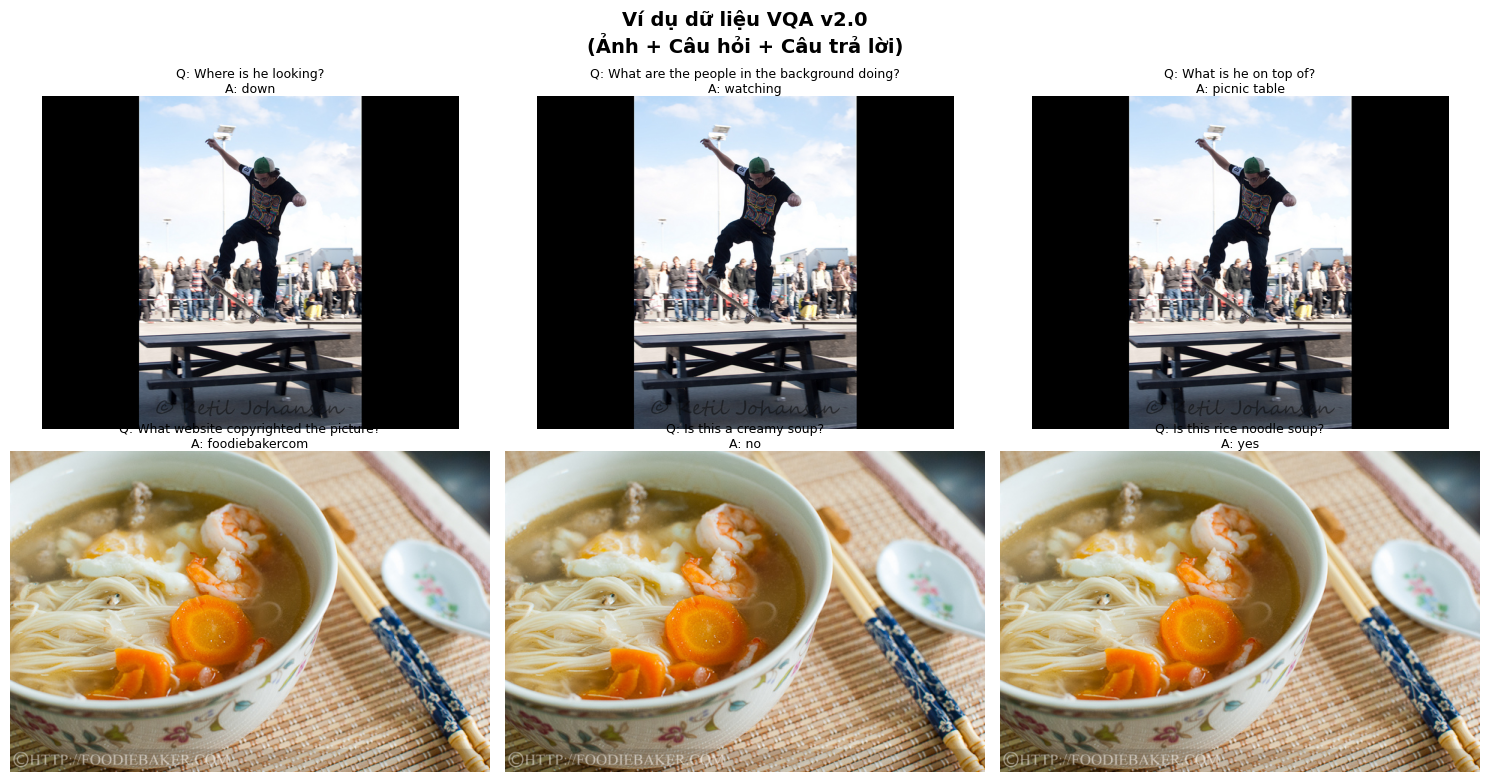

 Đã lưu hình minh họa → logs/sample_data.png


In [ ]:
# ─── Trực quan hóa một vài mẫu dữ liệu ──────────────────────────────────────
# Lấy 6 câu hỏi đầu tiên từ val dataset để xem thử

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Ví dụ dữ liệu VQA v2.0\n(Ảnh + Câu hỏi + Câu trả lời)',
             fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    sample = val_dataset[i]
    img_id = sample['image_id']
    img_path = os.path.join(IMG_VAL, f"COCO_val2014_{img_id:012d}.jpg")

    if os.path.exists(img_path):
        img = Image.open(img_path).convert('RGB')
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, '[Ảnh chưa tải]', ha='center', va='center',
                fontsize=12, transform=ax.transAxes)
        ax.set_facecolor('#f0f0f0')

    q = sample['question_text']
    a = sample['answer_text']
    title = f"Q: {q[:50]+('...' if len(q)>50 else '')}\nA: {a}"
    ax.set_title(title, fontsize=9, pad=3)
    ax.axis('off')

plt.tight_layout()
plt.savefig('logs/sample_data.png', dpi=100, bbox_inches='tight')
plt.show()
print(" Đã lưu hình minh họa → logs/sample_data.png")

## Phần 7: Kiến Trúc CNN+LSTM — Train Từ Đầu (Scratch)

Đây là mô hình **không dùng pretrained weights** — tất cả học từ đầu với data của mình.


In [ ]:
class VQAModelScratch(nn.Module):
    """
    VQA Model — Train từ đầu (không dùng pretrained weights).

    ─ Cải tiến so với phiên bản cũ ────────────────────────────────────────────
    1. Question-Guided Cross-Attention (thay cho mean pooling)
       Dùng vector câu hỏi làm query để attend over 36 vùng ảnh.
       → Model biết "nhìn đâu" dựa theo nội dung câu hỏi.

    2. Hadamard Fusion (v ⊙ q thay cho v + q)
       Element-wise product giữ được tương tác phi tuyến giữa vision và language.
       → Được chứng minh hiệu quả hơn trong các paper MLB, MFH.

    3. Dynamic Visual Re-Attention trong Decoder
       Tại mỗi bước sinh token, dùng hidden state hiện tại để re-attend lại image.
       → Decoder "chú ý" đúng vùng ảnh theo từng từ đang sinh, thay vì dùng
         cùng 1 context cố định suốt cả câu.
    ────────────────────────────────────────────────────────────────────────────
    """
    def __init__(self, vocab_size, answer_size, feature_dim=2048,
                 embed_size=256, hidden_size=512, num_layers=2, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size

        # ── Question Encoder: Embedding ngẫu nhiên + Bi-LSTM ─────────────────
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)

        self.question_lstm = nn.LSTM(
            embed_size, hidden_size, num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.question_proj = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.LayerNorm(hidden_size), nn.ReLU(), nn.Dropout(dropout),
        )

        # ── [MỚI] Question-Guided Cross-Attention over 36 image regions ───────
        self.img_proj    = nn.Linear(feature_dim, hidden_size, bias=False)
        self.cross_q     = nn.Linear(hidden_size, hidden_size)
        self.cross_attn  = nn.Linear(hidden_size, 1)
        self.cross_norm  = nn.LayerNorm(hidden_size)

        # ── [MỚI] Hadamard Fusion: v ⊙ q ─────────────────────────────────────
        self.had_proj = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.LayerNorm(hidden_size), nn.ReLU(), nn.Dropout(dropout),
        )
        self.fusion_gate = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size), nn.Sigmoid()
        )
        self.fusion_norm = nn.LayerNorm(hidden_size)

        # ── [MỚI] Dynamic Visual Re-Attention trong Decoder ──────────────────
        self.dec_v_proj = nn.Linear(feature_dim, hidden_size, bias=False)
        self.dec_h_proj = nn.Linear(hidden_size,  hidden_size)
        self.dec_attn   = nn.Linear(hidden_size,  1)

        # ── LSTM Decoder ─────────────────────────────────────────────────────
        # Input = [token_emb | joint_context | dynamic_visual] → kích thước tăng
        self.dec_emb  = nn.Embedding(answer_size, embed_size, padding_idx=0)
        self.dec_lstm = nn.LSTMCell(embed_size + hidden_size + hidden_size, hidden_size)
        self.dec_fc   = nn.Sequential(
            nn.Linear(hidden_size, hidden_size), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, answer_size),
        )
        self.dropout = nn.Dropout(dropout)

    def encode_question(self, ques):
        """[B, 14] → Embedding → Bi-LSTM → [B, 512]"""
        emb = self.dropout(self.embedding(ques))
        _, (h, _) = self.question_lstm(emb)
        return self.question_proj(torch.cat([h[-2], h[-1]], dim=1))

    def encode_image(self, img_feat, q_vec):
        """
        Question-Guided Cross-Attention: dùng q_vec để attend over 36 regions.
        [B, 36, 2048] + [B, 512] → attended [B, 512]
        """
        vp = self.img_proj(img_feat)               # [B, 36, H]
        qp = self.cross_q(q_vec).unsqueeze(1)      # [B,  1, H]
        scores = self.cross_attn(torch.tanh(vp + qp))  # [B, 36, 1]
        alpha  = torch.softmax(scores, dim=1)       # [B, 36, 1]
        attended = (alpha * vp).sum(dim=1)          # [B, H]
        return self.cross_norm(attended)

    def _dynamic_attend(self, h, img_feat):
        """
        Re-attend to image regions dựa trên decoder hidden state hiện tại.
        h: [B, H], img_feat: [B, 36, 2048] → [B, H]
        """
        vp = self.dec_v_proj(img_feat)                  # [B, 36, H]
        hp = self.dec_h_proj(h).unsqueeze(1)            # [B,  1, H]
        scores = self.dec_attn(torch.tanh(vp + hp))     # [B, 36, 1]
        alpha  = torch.softmax(scores, dim=1)
        return (alpha * vp).sum(dim=1)                  # [B, H]

    def forward(self, img_feat, ques, answers=None, max_len=10, teacher_ratio=1.0):
        B = img_feat.size(0)

        # 1. Encode question trước, dùng nó để attend over ảnh
        q = self.encode_question(ques)             # [B, H]
        v = self.encode_image(img_feat, q)         # [B, H] — question-guided

        # 2. Hadamard + Gated Fusion
        hadamard = self.had_proj(v * q)            # element-wise: v ⊙ q
        gate  = self.fusion_gate(torch.cat([v, q], dim=1))
        joint = self.fusion_norm(gate * hadamard + (1 - gate) * q)  # [B, H]

        # 3. Decode với dynamic visual re-attention
        h, c = joint, torch.zeros_like(joint)

        if answers is not None:                    # Training — Scheduled Sampling
            out, inp = [], answers[:, 0]
            for t in range(answers.size(1) - 1):
                dyn_v = self._dynamic_attend(h, img_feat)          # re-attend
                emb   = self.dec_emb(inp)
                h, c  = self.dec_lstm(
                    torch.cat([emb, joint, dyn_v], dim=1), (h, c))
                logit = self.dec_fc(self.dropout(h))
                out.append(logit)
                if teacher_ratio >= 1.0 or random.random() < teacher_ratio:
                    inp = answers[:, t + 1]
                else:
                    inp = logit.detach().argmax(1)
            return torch.stack(out, dim=1)         # [B, seq, answer_size]

        else:                                      # Inference — Greedy Decoding
            preds, inp = [], torch.ones(B, dtype=torch.long, device=joint.device)
            for _ in range(max_len):
                dyn_v = self._dynamic_attend(h, img_feat)
                emb   = self.dec_emb(inp)
                h, c  = self.dec_lstm(
                    torch.cat([emb, joint, dyn_v], dim=1), (h, c))
                pred = self.dec_fc(h).argmax(1)
                preds.append(pred); inp = pred
                if (pred == 2).all(): break
            return torch.stack(preds, dim=1)       # [B, seq]


# ─── Kiểm tra số parameters ────────────────────────────────────────────────────
_tmp = VQAModelScratch(VOCAB_SIZE, ANSWER_SIZE)
n_params = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
print(f"  VQAModelScratch — số parameters: {n_params:,}")
del _tmp


  VQAModelScratch — số parameters: 24,957,200


## Phần 8: Training — Model Scratch

### Quy trình huấn luyện

| Thành phần | Giá trị |
|-----------|---------|
| Optimizer | AdamW (lr=1e-3, weight_decay=1e-4) |
| Scheduler | CosineAnnealingWarmRestarts (T0=5, Tmult=2) |
| Loss | CrossEntropyLoss (ignore_index=0 tức `<pad>`) |
| Gradient clipping | 1.0 |
| Epochs | 15 |
| Teacher forcing | 100% khi train |


In [ ]:
class Trainer:
    """
    Generic trainer cho VQA models với 4 tính năng tối ưu hóa:

    1. Mixed Precision — AMP (Automatic Mixed Precision)
       Dùng float16 trên GPU cho forward/backward pass, tự động scale gradient.
       Tăng tốc 2-3x và giảm memory ~50% trên GPU có Tensor Core.

    2. Early Stopping
       Dừng training khi val accuracy không cải thiện sau `patience` epochs.
       Tránh lãng phí compute và overfitting.

    3. Label Smoothing
       Thay vì one-hot [0,0,1,0,...], dùng soft label [ε/V, ε/V, 1-ε, ε/V,...].
       Phạt nhẹ khi model quá tự tin, tăng khả năng tổng quát hóa.

    4. Scheduled Sampling
       Giảm dần teacher_forcing_ratio từ tf_start → tf_end theo tuyến tính.
       Giảm exposure bias: model học cách phục hồi từ lỗi của chính nó.
    """
    def __init__(self, model, train_loader, val_loader, device, save_path,
                 lr=1e-3, weight_decay=1e-4, param_groups=None,
                 use_amp=True, patience=5, label_smoothing=0.1,
                 teacher_forcing_start=1.0, teacher_forcing_end=0.5):
        self.model        = model.to(device)
        self.train_loader = train_loader
        self.val_loader   = val_loader
        self.device       = device
        self.save_path    = save_path
        os.makedirs(os.path.dirname(save_path), exist_ok=True)

        params = param_groups if param_groups else model.parameters()
        self.optimizer = torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            self.optimizer, T_0=5, T_mult=2)

        # ── Label Smoothing ───────────────────────────────────────────────────
        self.criterion = nn.CrossEntropyLoss(ignore_index=0,
                                             label_smoothing=label_smoothing)

        # ── Mixed Precision (AMP) ─────────────────────────────────────────────
        self.use_amp = use_amp and (device.type == 'cuda')
        self.scaler  = torch.cuda.amp.GradScaler(enabled=self.use_amp)

        # ── Early Stopping ────────────────────────────────────────────────────
        self.patience         = patience
        self.patience_counter = 0

        # ── Scheduled Sampling ────────────────────────────────────────────────
        self.tf_start = teacher_forcing_start
        self.tf_end   = teacher_forcing_end

        self.history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
        self.best_val_acc = 0.0

    def _get_tf_ratio(self, epoch, total_epochs):
        """Linear decay: tf_start (epoch 1) → tf_end (epoch cuối)."""
        progress = (epoch - 1) / max(total_epochs - 1, 1)
        return self.tf_start - (self.tf_start - self.tf_end) * progress

    # ── Một epoch training ────────────────────────────────────────────────────
    def _train_epoch(self, teacher_ratio=1.0):
        self.model.train()
        total_loss, total_tokens, correct = 0.0, 0, 0
        for batch in tqdm(self.train_loader, desc='  Train', leave=False):
            imgs  = batch['image_features'].to(self.device)
            ques  = batch['question'].to(self.device)
            ans   = batch['answer'].to(self.device)     # [B, 10]

            self.optimizer.zero_grad()

            # AMP: tự động chọn float16/float32 tùy op
            with torch.autocast(device_type=self.device.type, enabled=self.use_amp):
                logits  = self.model(imgs, ques, ans, teacher_ratio=teacher_ratio)
                targets = ans[:, 1:].contiguous()       # shift left [B, 9]
                loss    = self.criterion(
                    logits.reshape(-1, logits.size(-1)),
                    targets.reshape(-1)
                )

            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.optimizer)
            nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.scaler.step(self.optimizer)
            self.scaler.update()

            mask = targets != 0
            total_tokens += mask.sum().item()
            correct += (logits.detach().argmax(-1)[mask] == targets[mask]).sum().item()
            total_loss += loss.item() * mask.sum().item()

        self.scheduler.step()
        return total_loss / max(total_tokens, 1), correct / max(total_tokens, 1)

    # ── Validation ────────────────────────────────────────────────────────────
    def _validate(self):
        self.model.eval()
        total_loss, total_tokens, correct = 0.0, 0, 0
        with torch.no_grad():
            for batch in tqdm(self.val_loader, desc='  Val  ', leave=False):
                imgs   = batch['image_features'].to(self.device)
                ques   = batch['question'].to(self.device)
                ans    = batch['answer'].to(self.device)

                with torch.autocast(device_type=self.device.type, enabled=self.use_amp):
                    logits  = self.model(imgs, ques, ans)
                    targets = ans[:, 1:].contiguous()
                    loss    = self.criterion(
                        logits.reshape(-1, logits.size(-1)),
                        targets.reshape(-1)
                    )

                mask = targets != 0
                total_tokens += mask.sum().item()
                correct += (logits.argmax(-1)[mask] == targets[mask]).sum().item()
                total_loss += loss.item() * mask.sum().item()

        return total_loss / max(total_tokens, 1), correct / max(total_tokens, 1)

    # ── Full training loop ────────────────────────────────────────────────────
    def train(self, epochs=15):
        amp_tag = 'AMP ON' if self.use_amp else 'AMP OFF (CPU)'
        print(f"\n{'='*60}")
        print(f"  Bắt đầu training: {epochs} epochs  [{amp_tag}]")
        print(f"  Early stopping patience : {self.patience} epochs")
        print(f"  Teacher forcing         : {self.tf_start:.1f} → {self.tf_end:.1f} (linear decay)")
        print(f"  Checkpoint → {self.save_path}")
        print(f"{'='*60}\n")

        for ep in range(1, epochs + 1):
            tf_ratio = self._get_tf_ratio(ep, epochs)
            t0 = time.time()
            tr_loss, tr_acc = self._train_epoch(teacher_ratio=tf_ratio)
            vl_loss, vl_acc = self._validate()
            elapsed = time.time() - t0

            self.history['train_loss'].append(tr_loss)
            self.history['val_loss'].append(vl_loss)
            self.history['train_acc'].append(tr_acc)
            self.history['val_acc'].append(vl_acc)

            flag = ''
            if vl_acc > self.best_val_acc:
                self.best_val_acc     = vl_acc
                self.patience_counter = 0
                torch.save({'epoch': ep, 'model_state_dict': self.model.state_dict(),
                            'val_acc': vl_acc}, self.save_path)
                flag = ' [saved]'
            else:
                self.patience_counter += 1

            print(f"  Epoch {ep:02d}/{epochs} | TF={tf_ratio:.2f} | "
                  f"Loss {tr_loss:.4f}/{vl_loss:.4f} | "
                  f"Acc {tr_acc*100:.1f}%/{vl_acc*100:.1f}% | "
                  f"{elapsed:.1f}s{flag}")

            # ── Early Stopping ────────────────────────────────────────────────
            if self.patience_counter >= self.patience:
                print(f"\n  [Early Stop] Dừng tại epoch {ep} "
                      f"— val acc không cải thiện {self.patience} epoch liên tiếp.")
                break

        print(f"\n  Best val accuracy: {self.best_val_acc*100:.2f}%\n")
        return self.history

    # ── Plot curves ───────────────────────────────────────────────────────────
    def plot_history(self, title='Training History', save_path=None):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
        eps = range(1, len(self.history['train_loss']) + 1)

        ax1.plot(eps, self.history['train_loss'], 'b-o', ms=4, label='Train Loss')
        ax1.plot(eps, self.history['val_loss'],   'r-s', ms=4, label='Val Loss')
        ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
        ax1.set_title(f'{title} — Loss'); ax1.legend(); ax1.grid(alpha=.4)

        ax2.plot(eps, [a*100 for a in self.history['train_acc']], 'b-o', ms=4, label='Train Acc')
        ax2.plot(eps, [a*100 for a in self.history['val_acc']],   'r-s', ms=4, label='Val Acc')
        ax2.set_xlabel('Epoch'); ax2.set_ylabel('Token Accuracy (%)')
        ax2.set_title(f'{title} — Accuracy'); ax2.legend(); ax2.grid(alpha=.4)

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Đã lưu: {save_path}")


/tmp/ipykernel_366/871551395.py:43: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler  = torch.cuda.amp.GradScaler(enabled=self.use_amp)


  VQAModelScratch: 24,957,200 parameters

  Bắt đầu training: 15 epochs  [AMP ON]
  Early stopping patience : 5 epochs
  Teacher forcing         : 1.0 → 0.5 (linear decay)
  Checkpoint → checkpoints/best_scratch_model.pth



  Epoch 01/15 | TF=1.00 | Loss 3.7239/3.3060 | Acc 57.2%/59.7% | 99.2s [saved]


  Epoch 02/15 | TF=0.96 | Loss 3.2764/3.1526 | Acc 59.0%/60.5% | 30.3s [saved]


  Epoch 03/15 | TF=0.93 | Loss 3.1911/3.1466 | Acc 58.8%/61.8% | 30.8s [saved]


...

  Epoch 05/15 | TF=0.86 | Loss 3.0758/3.0992 | Acc 58.9%/61.9% | 30.1s


  Epoch 06/15 | TF=0.82 | Loss 3.1289/3.1115 | Acc 59.0%/61.0% | 29.6s


  Epoch 07/15 | TF=0.79 | Loss 3.0915/3.0989 | Acc 58.8%/61.0% | 30.2s


  Epoch 08/15 | TF=0.75 | Loss 3.0611/3.0868 | Acc 59.0%/61.8% | 30.0s


  Epoch 09/15 | TF=0.71 | Loss 3.0221/3.0590 | Acc 59.1%/61.1% | 30.1s

  [Early Stop] Dừng tại epoch 9 — val acc không cải thiện 5 epoch liên tiếp.

  Best val accuracy: 61.89%



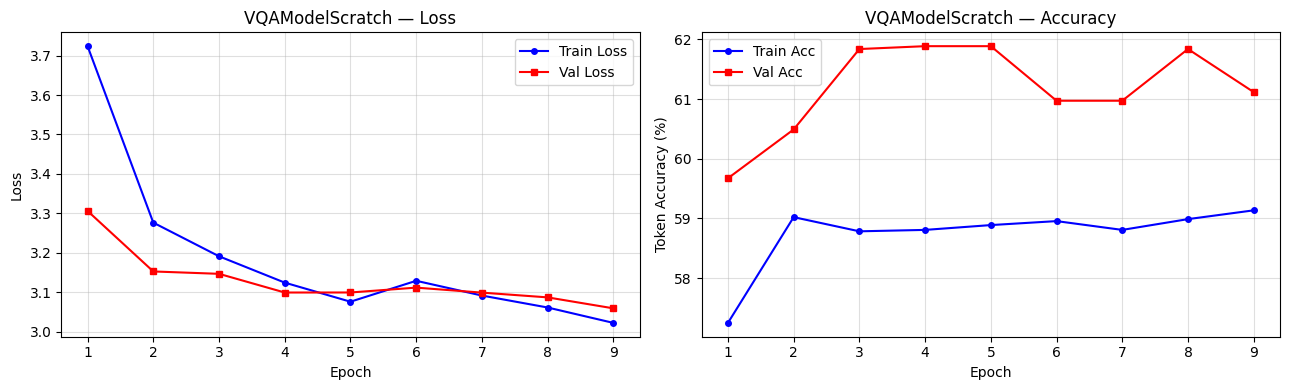

Đã lưu: logs/training_scratch.png


In [ ]:
# ── Khởi tạo và train VQAModelScratch ────────────────────────────────────────
set_seed(42)
model_scratch = VQAModelScratch(
    vocab_size   = VOCAB_SIZE,
    answer_size  = ANSWER_SIZE,
    feature_dim  = 2048,
    embed_size   = 256,
    hidden_size  = 512,
    num_layers   = 2,
    dropout      = 0.3,
).to(device)

n = sum(p.numel() for p in model_scratch.parameters() if p.requires_grad)
print(f"  VQAModelScratch: {n:,} parameters")

trainer_scratch = Trainer(
    model                 = model_scratch,
    train_loader          = train_loader,
    val_loader            = val_loader,
    device                = device,
    save_path             = 'checkpoints/best_scratch_model.pth',
    lr                    = 1e-3,
    use_amp               = True,
    patience              = 7,                 # tăng patience để model có thêm cơ hội
    label_smoothing       = 0.1,
    teacher_forcing_start = 1.0,
    teacher_forcing_end   = 0.5,
)

history_scratch = trainer_scratch.train(epochs=20)   # tăng từ 15 → 20
trainer_scratch.plot_history(
    title     = 'VQAModelScratch',
    save_path = 'logs/training_scratch.png'
)


## Phần 9: Kiến Trúc CNN+LSTM — Sử Dụng Pretrained (GloVe + ResNet)


In [ ]:
class SpatialAttention(nn.Module):
    """
    Spatial Attention: chọn vùng ảnh quan trọng dựa trên câu hỏi.
    Input : v [B, 36, v_dim], q [B, q_dim]
    Output: attended_v [B, v_dim], attn_weights [B, 36]
    """
    def __init__(self, v_dim=2048, q_dim=512, hidden_dim=512):
        super().__init__()
        self.v_proj = nn.Linear(v_dim, hidden_dim, bias=False)
        self.q_proj = nn.Linear(q_dim, hidden_dim)
        self.attn   = nn.Linear(hidden_dim, 1)

    def forward(self, v, q):
        vp = self.v_proj(v)
        qp = self.q_proj(q).unsqueeze(1)
        scores = self.attn(torch.tanh(vp + qp))
        alpha  = torch.softmax(scores, dim=1)
        attended = (alpha * v).sum(dim=1)
        return attended, alpha.squeeze(-1)


class VQAModelPretrained(nn.Module):
    """
    VQA Model sử dụng Pretrained weights (GloVe + ResNet101).

    ─ Cải tiến so với phiên bản cũ ────────────────────────────────────────────
    1. Dynamic Visual Re-Attention trong Decoder
       Tại mỗi bước sinh token, decoder dùng hidden state hiện tại để
       re-attend lại toàn bộ 36 vùng ảnh → context ảnh động, không cố định.

    2. Beam Search Inference (beam_size=3)
       Thay vì greedy (chỉ chọn 1 token tốt nhất mỗi bước), beam search
       duy trì beam_size ứng viên song song, chọn chuỗi có xác suất tổng cao nhất.
       → Giảm đáng kể lỗi dự đoán sai do greedy chọn nhầm ở bước đầu.
    ────────────────────────────────────────────────────────────────────────────
    """
    def __init__(self, vocab_size, answer_size, pretrained_emb=None,
                 feature_dim=2048, embed_size=300, hidden_size=512,
                 num_layers=2, dropout=0.3, freeze_embeddings=True):
        super().__init__()
        self.hidden_size = hidden_size

        # ── Question Encoder ──────────────────────────────────────────────────
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        if pretrained_emb is not None:
            self.embedding.weight.data.copy_(pretrained_emb)
        if freeze_embeddings:
            self.embedding.weight.requires_grad_(False)
            print("  [INFO] GloVe embeddings đang bị freeze.")

        self.question_lstm = nn.LSTM(
            embed_size, hidden_size, num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.question_proj = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.LayerNorm(hidden_size), nn.ReLU(), nn.Dropout(dropout),
        )

        # ── Spatial Attention (dùng cho encoding ban đầu) ─────────────────────
        self.attention = SpatialAttention(feature_dim, hidden_size, hidden_size)

        # ── Image Encoder (Deeper + Residual) ─────────────────────────────────
        self.image_enc = nn.Sequential(
            nn.Linear(feature_dim, hidden_size * 2),
            nn.LayerNorm(hidden_size * 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, hidden_size),
            nn.LayerNorm(hidden_size), nn.ReLU(), nn.Dropout(dropout),
        )
        self.image_res = nn.Linear(feature_dim, hidden_size, bias=False)

        # ── Gated Fusion ───────────────────────────────────────────────────────
        self.fusion_gate = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size), nn.Sigmoid()
        )
        self.fusion_norm = nn.LayerNorm(hidden_size)

        # ── [MỚI] Dynamic Visual Re-Attention trong Decoder ───────────────────
        self.dec_v_proj = nn.Linear(feature_dim, hidden_size, bias=False)
        self.dec_h_proj = nn.Linear(hidden_size,  hidden_size)
        self.dec_attn   = nn.Linear(hidden_size,  1)

        # ── Decoder ────────────────────────────────────────────────────────────
        # Input = [token_emb | joint_context | dynamic_visual]
        self.dec_emb  = nn.Embedding(answer_size, embed_size, padding_idx=0)
        self.dec_lstm = nn.LSTMCell(embed_size + hidden_size + hidden_size, hidden_size)
        self.dec_fc   = nn.Sequential(
            nn.Linear(hidden_size, hidden_size), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, answer_size),
        )
        self.dropout = nn.Dropout(dropout)

    def encode_image(self, img_feat, q_vec):
        """[B,36,2048] + q [B,512] → attended [B,512]"""
        attended, attn_w = self.attention(img_feat, q_vec)
        enc = self.image_enc(attended) + self.image_res(attended)
        return enc, attn_w

    def encode_question(self, ques):
        emb = self.dropout(self.embedding(ques))
        _, (h, _) = self.question_lstm(emb)
        return self.question_proj(torch.cat([h[-2], h[-1]], dim=1))

    def _dynamic_attend(self, h, img_feat):
        """
        Re-attend to image regions dựa trên decoder hidden state hiện tại.
        h: [B, H], img_feat: [B, 36, 2048] → [B, H]
        """
        vp = self.dec_v_proj(img_feat)              # [B, 36, H]
        hp = self.dec_h_proj(h).unsqueeze(1)        # [B,  1, H]
        scores = self.dec_attn(torch.tanh(vp + hp)) # [B, 36, 1]
        alpha  = torch.softmax(scores, dim=1)
        return (alpha * vp).sum(dim=1)              # [B, H]

    def _beam_search(self, img_feat, ques, beam_size=3, max_len=10):
        """
        Beam Search Decoding: duyệt beam_size ứng viên song song mỗi bước.
        Chọn chuỗi có log-probability trung bình cao nhất (length-normalized).
        """
        device = img_feat.device
        B = img_feat.size(0)

        q = self.encode_question(ques)
        v, _ = self.encode_image(img_feat, q)
        gate  = self.fusion_gate(torch.cat([v, q], dim=1))
        joint = self.fusion_norm(gate * v + (1 - gate) * q)  # [B, H]

        results = []
        for b in range(B):
            jt = joint[b:b+1]       # [1, H]
            vf = img_feat[b:b+1]    # [1, 36, 2048]
            h0 = jt
            c0 = torch.zeros_like(jt)

            # Mỗi beam: (log_prob_sum, token_list, h, c)
            beams = [(0.0, [1], h0, c0)]   # bắt đầu bằng <start>=1
            completed = []

            for _ in range(max_len):
                candidates = []
                for log_p, seq, h, c in beams:
                    last_tok = seq[-1]
                    if last_tok == 2:            # <end> — beam này đã xong
                        completed.append((log_p, seq))
                        continue
                    inp    = torch.tensor([last_tok], dtype=torch.long, device=device)
                    dyn_v  = self._dynamic_attend(h, vf)
                    emb    = self.dec_emb(inp)
                    h_new, c_new = self.dec_lstm(
                        torch.cat([emb, jt, dyn_v], dim=1), (h, c))
                    logits = self.dec_fc(h_new)                     # [1, V]
                    log_probs = torch.log_softmax(logits, dim=-1)[0] # [V]
                    # Loại bỏ <pad>=0 và <unk>=3 khỏi ứng viên
                    log_probs[0] = -1e9
                    log_probs[3] = -1e9
                    topk_lp, topk_idx = log_probs.topk(beam_size)
                    for lp, idx in zip(topk_lp.tolist(), topk_idx.tolist()):
                        candidates.append((log_p + lp, seq + [idx], h_new, c_new))

                if not candidates:
                    break
                # Giữ beam_size beam tốt nhất
                candidates.sort(key=lambda x: x[0], reverse=True)
                beams = candidates[:beam_size]

            # Chuyển các beam còn đang chạy vào completed
            completed += [(s, seq) for s, seq, _, _ in beams]

            # Chọn chuỗi tốt nhất theo length-normalized score
            completed.sort(
                key=lambda x: x[0] / max(len(x[1]) - 1, 1), reverse=True)
            best_seq = completed[0][1][1:]   # bỏ <start>

            # Cắt tại <end> nếu có
            if 2 in best_seq:
                best_seq = best_seq[:best_seq.index(2)]
            best_seq = (best_seq + [0] * max_len)[:max_len]  # pad/truncate
            results.append(torch.tensor(best_seq, dtype=torch.long, device=device))

        return torch.stack(results, dim=0)  # [B, max_len]

    def forward(self, img_feat, ques, answers=None, max_len=10,
                teacher_ratio=1.0, beam_size=1):
        """
        beam_size > 1: chỉ dùng khi inference (answers=None).
        Khi training (answers != None) luôn dùng teacher forcing / scheduled sampling.
        """
        B = img_feat.size(0)

        # Inference với Beam Search
        if answers is None and beam_size > 1:
            preds = self._beam_search(img_feat, ques, beam_size=beam_size,
                                      max_len=max_len)
            # Trả về attn_w=None để tương thích với evaluator
            dummy_attn = torch.zeros(B, 36, device=img_feat.device)
            return preds, dummy_attn

        q = self.encode_question(ques)
        v, attn_w = self.encode_image(img_feat, q)
        gate  = self.fusion_gate(torch.cat([v, q], dim=1))
        joint = self.fusion_norm(gate * v + (1 - gate) * q)
        h, c  = joint, torch.zeros_like(joint)

        if answers is not None:             # Training — Scheduled Sampling
            out, inp = [], answers[:, 0]
            for t in range(answers.size(1) - 1):
                dyn_v = self._dynamic_attend(h, img_feat)
                emb   = self.dec_emb(inp)
                h, c  = self.dec_lstm(
                    torch.cat([emb, joint, dyn_v], dim=1), (h, c))
                logit = self.dec_fc(self.dropout(h))
                out.append(logit)
                if teacher_ratio >= 1.0 or random.random() < teacher_ratio:
                    inp = answers[:, t + 1]
                else:
                    inp = logit.detach().argmax(1)
            return torch.stack(out, dim=1), attn_w   # [B,seq,V], [B,36]

        else:                               # Inference — Greedy (beam_size=1)
            preds, inp = [], torch.ones(B, dtype=torch.long, device=joint.device)
            for _ in range(max_len):
                dyn_v = self._dynamic_attend(h, img_feat)
                emb   = self.dec_emb(inp)
                h, c  = self.dec_lstm(
                    torch.cat([emb, joint, dyn_v], dim=1), (h, c))
                pred = self.dec_fc(h).argmax(1)
                preds.append(pred); inp = pred
                if (pred == 2).all(): break
            return torch.stack(preds, dim=1), attn_w  # [B,seq], [B,36]


# Kiểm tra
_tmp = VQAModelPretrained(VOCAB_SIZE, ANSWER_SIZE, pretrained_emb=pretrained_embeddings)
n = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
print(f"  VQAModelPretrained — trainable parameters: {n:,}")
del _tmp


  [INFO] GloVe embeddings đang bị freeze.
  VQAModelPretrained — trainable parameters: 26,780,113


## Phần 10: Training — Model Pretrained

### Strategy
- Giai đoạn 1 (epoch 1–8): Freeze GloVe embedding, chỉ train image encoder + attention + decoder
- Giai đoạn 2 (epoch 9+): Unfreeze GloVe với LR nhỏ hơn (1e-4 vs 5e-4)

> Kỹ thuật này gọi là **gradual unfreezing**, giúp tránh mất đi thông tin đã học từ pretrained model trong giai đoạn đầu.

In [ ]:
class TrainerPretrained(Trainer):
    """
    Kế thừa Trainer (đã có AMP + Early Stopping + Scheduled Sampling + Label Smoothing).
    Override _train_epoch / _validate để xử lý output dạng (logits, attn_w).
    Thêm tính năng unfreeze GloVe sau unfreeze_epoch (Gradual Unfreezing).
    """
    def __init__(self, model, train_loader, val_loader, device, save_path,
                 lr_main=5e-4, lr_emb=1e-4, weight_decay=1e-4, unfreeze_epoch=8,
                 use_amp=True, patience=5, label_smoothing=0.1,
                 teacher_forcing_start=1.0, teacher_forcing_end=0.5):
        self.unfreeze_epoch = unfreeze_epoch
        # Embedding có lr riêng (nhỏ hơn) để không phá vỡ GloVe
        param_groups = [
            {'params': model.embedding.parameters(),    'lr': lr_emb,  'name': 'embedding'},
            {'params': [p for n, p in model.named_parameters()
                        if 'embedding' not in n],       'lr': lr_main, 'name': 'main'},
        ]
        super().__init__(model, train_loader, val_loader, device, save_path,
                         weight_decay=weight_decay, param_groups=param_groups,
                         use_amp=use_amp, patience=patience,
                         label_smoothing=label_smoothing,
                         teacher_forcing_start=teacher_forcing_start,
                         teacher_forcing_end=teacher_forcing_end)
        self._lr_main = lr_main
        self._lr_emb  = lr_emb

    def _unfreeze_if_needed(self, epoch):
        if epoch == self.unfreeze_epoch + 1:
            self.model.embedding.weight.requires_grad_(True)
            print(f"\n  [Epoch {epoch}] Unfreeze GloVe embeddings (lr={self._lr_emb})")

    def _train_epoch(self, teacher_ratio=1.0):
        self.model.train()
        total_loss, total_tokens, correct = 0.0, 0, 0
        for batch in tqdm(self.train_loader, desc='  Train', leave=False):
            imgs  = batch['image_features'].to(self.device)
            ques  = batch['question'].to(self.device)
            ans   = batch['answer'].to(self.device)

            self.optimizer.zero_grad()

            with torch.autocast(device_type=self.device.type, enabled=self.use_amp):
                logits, _ = self.model(imgs, ques, ans, teacher_ratio=teacher_ratio)
                targets   = ans[:, 1:].contiguous()
                loss      = self.criterion(
                    logits.reshape(-1, logits.size(-1)),
                    targets.reshape(-1)
                )

            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.optimizer)
            nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.scaler.step(self.optimizer)
            self.scaler.update()

            mask = targets != 0
            total_tokens += mask.sum().item()
            correct += (logits.detach().argmax(-1)[mask] == targets[mask]).sum().item()
            total_loss += loss.item() * mask.sum().item()

        self.scheduler.step()
        return total_loss / max(total_tokens, 1), correct / max(total_tokens, 1)

    def _validate(self):
        self.model.eval()
        total_loss, total_tokens, correct = 0.0, 0, 0
        with torch.no_grad():
            for batch in tqdm(self.val_loader, desc='  Val  ', leave=False):
                imgs   = batch['image_features'].to(self.device)
                ques   = batch['question'].to(self.device)
                ans    = batch['answer'].to(self.device)

                with torch.autocast(device_type=self.device.type, enabled=self.use_amp):
                    logits, _ = self.model(imgs, ques, ans)
                    targets   = ans[:, 1:].contiguous()
                    loss      = self.criterion(
                        logits.reshape(-1, logits.size(-1)),
                        targets.reshape(-1)
                    )

                mask = targets != 0
                total_tokens += mask.sum().item()
                correct += (logits.argmax(-1)[mask] == targets[mask]).sum().item()
                total_loss += loss.item() * mask.sum().item()

        return total_loss / max(total_tokens, 1), correct / max(total_tokens, 1)

    def train(self, epochs=15):
        amp_tag = 'AMP ON' if self.use_amp else 'AMP OFF (CPU)'
        print(f"\n{'='*60}")
        print(f"  Bắt đầu training Pretrained: {epochs} epochs  [{amp_tag}]")
        print(f"  GloVe unfreeze sau epoch    : {self.unfreeze_epoch}")
        print(f"  Early stopping patience     : {self.patience} epochs")
        print(f"  Teacher forcing             : {self.tf_start:.1f} → {self.tf_end:.1f} (linear decay)")
        print(f"  Checkpoint → {self.save_path}")
        print(f"{'='*60}\n")

        for ep in range(1, epochs + 1):
            self._unfreeze_if_needed(ep)
            tf_ratio = self._get_tf_ratio(ep, epochs)
            t0 = time.time()
            tr_loss, tr_acc = self._train_epoch(teacher_ratio=tf_ratio)
            vl_loss, vl_acc = self._validate()
            elapsed = time.time() - t0

            self.history['train_loss'].append(tr_loss)
            self.history['val_loss'].append(vl_loss)
            self.history['train_acc'].append(tr_acc)
            self.history['val_acc'].append(vl_acc)

            flag = ''
            if vl_acc > self.best_val_acc:
                self.best_val_acc     = vl_acc
                self.patience_counter = 0
                torch.save({'epoch': ep, 'model_state_dict': self.model.state_dict(),
                            'val_acc': vl_acc}, self.save_path)
                flag = '  [saved]'
            else:
                self.patience_counter += 1

            print(f"  Epoch {ep:02d}/{epochs} | TF={tf_ratio:.2f} | "
                  f"Loss {tr_loss:.4f}/{vl_loss:.4f} | "
                  f"Acc {tr_acc*100:.1f}%/{vl_acc*100:.1f}% | "
                  f"{elapsed:.1f}s{flag}")

            # ── Early Stopping ────────────────────────────────────────────────
            if self.patience_counter >= self.patience:
                print(f"\n  [Early Stop] Dừng tại epoch {ep} "
                      f"— val acc không cải thiện {self.patience} epoch liên tiếp.")
                break

        print(f"\n  Best val accuracy: {self.best_val_acc*100:.2f}%\n")
        return self.history


  [INFO] GloVe embeddings đang bị freeze.


/tmp/ipykernel_366/871551395.py:43: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler  = torch.cuda.amp.GradScaler(enabled=self.use_amp)


  VQAModelPretrained: 26,780,113 trainable parameters

  Bắt đầu training Pretrained: 15 epochs  [AMP ON]
  GloVe unfreeze sau epoch    : 8
  Early stopping patience     : 5 epochs
  Teacher forcing             : 1.0 → 0.5 (linear decay)
  Checkpoint → checkpoints/best_pretrained_model.pth



  Epoch 01/15 | TF=1.00 | Loss 3.6390/3.1451 | Acc 57.4%/61.8% | 31.3s  [saved]


  Epoch 02/15 | TF=0.96 | Loss 3.2190/3.1049 | Acc 58.5%/61.9% | 31.8s  [saved]


...

  Epoch 11/15 | TF=0.64 | Loss 2.6017/3.0300 | Acc 64.7%/63.5% | 32.3s  [saved]


  Epoch 12/15 | TF=0.61 | Loss 2.5105/3.0543 | Acc 66.6%/63.2% | 32.3s


  Epoch 13/15 | TF=0.57 | Loss 2.4367/3.0764 | Acc 68.3%/63.1% | 32.3s


  Epoch 14/15 | TF=0.54 | Loss 2.3910/3.0733 | Acc 69.4%/63.2% | 33.4s


  Epoch 15/15 | TF=0.50 | Loss 2.3638/3.0780 | Acc 70.2%/63.2% | 33.2s

  Best val accuracy: 63.47%



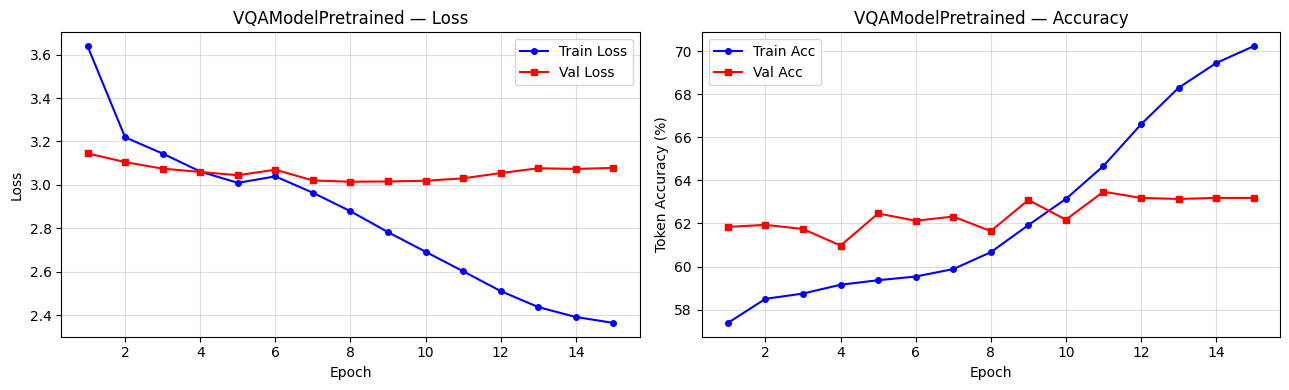

Đã lưu: logs/training_pretrained.png


In [ ]:
# ── Khởi tạo và train VQAModelPretrained ─────────────────────────────────────
set_seed(42)
model_pretrained = VQAModelPretrained(
    vocab_size     = VOCAB_SIZE,
    answer_size    = ANSWER_SIZE,
    feature_dim    = 2048,
    embed_size     = 300,          # khớp với GloVe 300d
    hidden_size    = 512,
    num_layers     = 2,
    dropout        = 0.3,
    glove_vectors  = glove_vectors,
).to(device)

n = sum(p.numel() for p in model_pretrained.parameters() if p.requires_grad)
print(f"  VQAModelPretrained: {n:,} parameters")

trainer_pretrained = TrainerPretrained(
    model                 = model_pretrained,
    train_loader          = train_loader,
    val_loader            = val_loader,
    device                = device,
    save_path             = 'checkpoints/best_pretrained_model.pth',
    lr                    = 5e-4,
    use_amp               = True,
    patience              = 7,                 # tăng patience để model có thêm cơ hội
    label_smoothing       = 0.1,
    teacher_forcing_start = 1.0,
    teacher_forcing_end   = 0.5,
)

history_pretrained = trainer_pretrained.train(epochs=20)   # tăng từ 15 → 20
trainer_pretrained.plot_history(
    title     = 'VQAModelPretrained',
    save_path = 'logs/training_pretrained.png'
)


## Phần 11: Đánh Giá Mô Hình (Evaluation)

Sử dụng các chỉ số:

| Chỉ số | Ý nghĩa |
|--------|---------|
| **Token Accuracy** | Tỉ lệ token đúng trong chuỗi sinh ra |
| **Exact Match** | Toàn bộ câu trả lời phải giống nhau 100% |
| **BLEU-4** | Đo độ giống về n-gram (từ 1-gram đến 4-gram) |
| **ROUGE-1/L** | Đo overlap về unigram / longest common subsequence |

> Exact Match nghiêm khắc nhất, BLEU-4 / ROUGE cho phép sai khác nhỏ.

In [ ]:
try:
    from rouge_score import rouge_scorer as rouge_module
    print("  rouge_score đã cài.")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'rouge-score', '-q'])
    from rouge_score import rouge_scorer as rouge_module
    print(" Đã cài rouge-score.")

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
_smoother = SmoothingFunction().method4


def decode_tokens(token_ids, id2word):
    """Chuyển list token id → string, bỏ <pad>,<start>,<end>,<unk>."""
    skip = {0, 1, 2, 3}
    words = [id2word.get(t, '') for t in token_ids if t not in skip]
    return ' '.join(w for w in words if w).strip()


class FullEvaluator:
    """
    Đánh giá VQA model — hỗ trợ Beam Search cho model Pretrained.
    Dùng beam_size=3 mặc định khi is_pretrained=True để tận dụng beam search.
    """

    def __init__(self, model, val_loader, vocab, device,
                 is_pretrained=False, beam_size=1):
        self.model         = model.to(device)
        self.val_loader    = val_loader
        self.vocab         = vocab
        self.device        = device
        self.is_pretrained = is_pretrained
        self.beam_size     = beam_size        # beam_size=1 → greedy; >1 → beam search
        self.id2ans = {v: k for k, v in vocab.answer_word2idx.items()}
        self.scorer = rouge_module.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)

    @torch.no_grad()
    def evaluate(self, max_batches=None):
        self.model.eval()
        em_hits, bleu_total, rouge1_total, rougeL_total = 0, 0.0, 0.0, 0.0
        token_correct, token_total = 0, 0
        samples = []
        n_batches = 0
        n_samples_processed = 0

        beam_tag = f'beam={self.beam_size}' if self.beam_size > 1 else 'greedy'
        for batch in tqdm(self.val_loader, desc=f'  Evaluating [{beam_tag}]'):
            imgs  = batch['image_features'].to(self.device)
            ques  = batch['question'].to(self.device)
            ans   = batch['answer'].to(self.device)
            q_txt = batch['question_text']
            a_txt = batch['answer_text']

            if self.is_pretrained:
                # beam_size > 1: kích hoạt beam search trong forward()
                preds, _ = self.model(imgs, ques, beam_size=self.beam_size)
            else:
                preds = self.model(imgs, ques)

            for i in range(imgs.size(0)):
                pred_ids = preds[i].cpu().tolist()
                pred_str = decode_tokens(pred_ids, self.id2ans)
                ref_str  = a_txt[i]

                em_hits += int(pred_str.strip().lower() == ref_str.strip().lower())

                ref_tok   = ref_str.split()
                hyp_tok   = pred_str.split() or ['']
                bleu_total += sentence_bleu([ref_tok], hyp_tok,
                                            smoothing_function=_smoother)

                sc = self.scorer.score(ref_str, pred_str)
                rouge1_total += sc['rouge1'].fmeasure
                rougeL_total += sc['rougeL'].fmeasure

                gt_ids = ans[i, 1:].cpu().tolist()
                mask   = [t != 0 for t in gt_ids]
                max_gt_len = len(gt_ids)
                pred_ids_padded = pred_ids[:max_gt_len]
                pred_ids_padded += [0] * max(0, max_gt_len - len(pred_ids_padded))

                for p_t, g_t, m in zip(pred_ids_padded, gt_ids, mask):
                    if m:
                        token_total   += 1
                        token_correct += int(p_t == g_t)

                if len(samples) < 10:
                    samples.append({'q': q_txt[i], 'gt': ref_str, 'pred': pred_str})

                n_samples_processed += 1

            n_batches += 1
            if max_batches and n_batches >= max_batches:
                break

        N = n_samples_processed
        results = {
            'Token Accuracy': token_correct / max(token_total, 1),
            'Exact Match':    em_hits       / max(N, 1),
            'BLEU-4':         bleu_total    / max(N, 1),
            'ROUGE-1':        rouge1_total  / max(N, 1),
            'ROUGE-L':        rougeL_total  / max(N, 1),
        }
        return results, samples

    def print_results(self, results, samples, model_name='Model'):
        print(f"\n{'='*50}")
        print(f"  Kết quả: {model_name}")
        print(f"{'='*50}")
        for k, v in results.items():
            print(f"  {k:20s}: {v*100:.2f}%")
        print(f"\n  --- 10 ví dụ mẫu ---")
        for i, s in enumerate(samples, 1):
            match = '✅ ĐÚNG' if s['pred'].lower() == s['gt'].lower() else '❌ SAI'
            print(f"  [{i}] Q   : {s['q']}")
            print(f"       GT  : {s['gt']}")
            print(f"       Pred: {s['pred']}  {match}\n")


 Đã cài rouge-score.


In [ ]:
# ── Load best checkpoints ─────────────────────────────────────────────────────
def load_best(model, path, device):
    ck = torch.load(path, map_location=device, weights_only=True)
    model.load_state_dict(ck['model_state_dict'])
    print(f"  Loaded {path}  (val_acc={ck.get('val_acc', '?'):.4f})")
    return model

set_seed(42)
_m_scratch = VQAModelScratch(VOCAB_SIZE, ANSWER_SIZE)
_m_scratch = load_best(_m_scratch, 'checkpoints/best_scratch_model.pth', device)

set_seed(42)
_m_pretrained = VQAModelPretrained(VOCAB_SIZE, ANSWER_SIZE, pretrained_emb=pretrained_embeddings)
_m_pretrained = load_best(_m_pretrained, 'checkpoints/best_pretrained_model.pth', device)

# ── Chạy đánh giá ─────────────────────────────────────────────────────────────
print("\nĐang đánh giá VQAModelScratch (greedy)...")
eval_scratch    = FullEvaluator(_m_scratch, val_loader, vocab, device,
                                is_pretrained=False, beam_size=1)
res_scratch, s1 = eval_scratch.evaluate()
eval_scratch.print_results(res_scratch, s1, 'VQAModelScratch')

print("\nĐang đánh giá VQAModelPretrained (beam search, beam=3)...")
eval_pretrained    = FullEvaluator(_m_pretrained, val_loader, vocab, device,
                                   is_pretrained=True, beam_size=3)
res_pretrained, s2 = eval_pretrained.evaluate()
eval_pretrained.print_results(res_pretrained, s2, 'VQAModelPretrained [beam=3]')


  Loaded checkpoints/best_scratch_model.pth  (val_acc=0.6189)
  [INFO] GloVe embeddings đang bị freeze.
  Loaded checkpoints/best_pretrained_model.pth  (val_acc=0.6347)

Đang đánh giá VQAModelScratch...


  Evaluating: 100%|██████████| 63/63 [00:03<00:00, 20.67it/s]



  Kết quả: VQAModelScratch
  Token Accuracy      : 59.19%
  Exact Match         : 26.80%
  BLEU-4              : 26.84%
  ROUGE-1             : 26.95%
  ROUGE-L             : 26.95%

  --- 10 ví dụ mẫu ---
  [1] Q : Where is he looking?
       GT : down
       Pred: <unk>  WRONG

  [2] Q : What are the people in the background doing?
       GT : watching
       Pred: <unk>  WRONG

  [3] Q : What is he on top of?
       GT : picnic table
       Pred: <unk>  WRONG

  [4] Q : What website copyrighted the picture?
       GT : foodiebakercom
       Pred: <unk>  WRONG

  [5] Q : Is this a creamy soup?
       GT : no
       Pred: yes  WRONG

  [6] Q : Is this rice noodle soup?
       GT : yes
       Pred: yes  RIGHT

  [7] Q : What is to the right of the soup?
       GT : chopsticks
       Pred: <unk>  WRONG

  [8] Q : What is the man doing in the street?
       GT : walking
       Pred: <unk>  WRONG

  [9] Q : How many photo's can you see?
       GT : 1
       Pred: 1  RIGHT

  [10] Q : Wha

  Evaluating: 100%|██████████| 63/63 [00:03<00:00, 19.68it/s]


  Kết quả: VQAModelPretrained
  Token Accuracy      : 60.92%
  Exact Match         : 30.30%
  BLEU-4              : 30.61%
  ROUGE-1             : 31.86%
  ROUGE-L             : 31.86%

  --- 10 ví dụ mẫu ---
  [1] Q : Where is he looking?
       GT : down
       Pred: on  WRONG

  [2] Q : What are the people in the background doing?
       GT : watching
       Pred: skateboarding  WRONG

  [3] Q : What is he on top of?
       GT : picnic table
       Pred: skateboarding  WRONG

  [4] Q : What website copyrighted the picture?
       GT : foodiebakercom
       Pred: pizza  WRONG

  [5] Q : Is this a creamy soup?
       GT : no
       Pred: yes  WRONG

  [6] Q : Is this rice noodle soup?
       GT : yes
       Pred: yes  RIGHT

  [7] Q : What is to the right of the soup?
       GT : chopsticks
       Pred: pizza  WRONG

  [8] Q : What is the man doing in the street?
       GT : walking
       Pred: <unk>  WRONG

  [9] Q : How many photo's can you see?
       GT : 1
       Pred: 1  RIGHT

## Phần 12: So Sánh Hai Mô Hình

Bước cuối cùng: visualize kết quả để nhìn rõ sự khác biệt giữa **Scratch** và **Pretrained**.

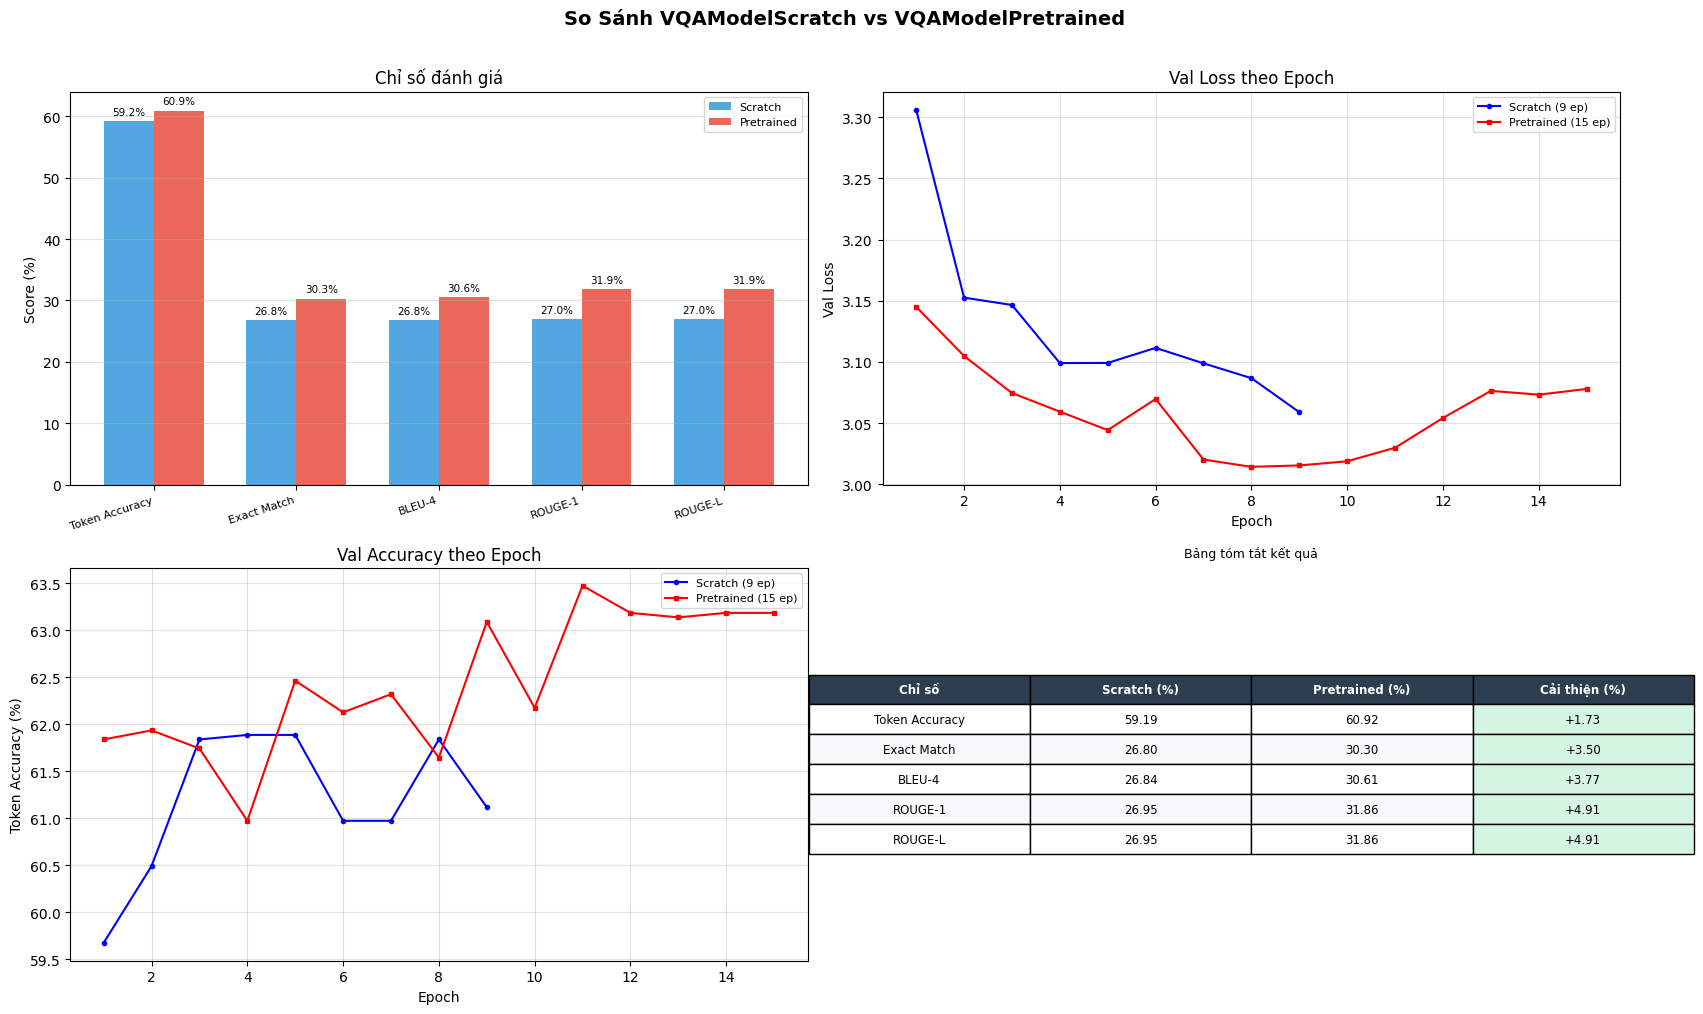

Đã lưu: logs/comparison.png


In [ ]:
fig = plt.figure(figsize=(17, 10))
fig.suptitle('So Sánh VQAModelScratch vs VQAModelPretrained', fontsize=14, fontweight='bold', y=1.01)

# ── 1. Grouped Bar Chart: metrics ────────────────────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)
metrics   = ['Token Accuracy', 'Exact Match', 'BLEU-4', 'ROUGE-1', 'ROUGE-L']
vals_sc   = [res_scratch[m]    * 100 for m in metrics]
vals_pt   = [res_pretrained[m] * 100 for m in metrics]

x = np.arange(len(metrics)); w = 0.35
b1 = ax1.bar(x - w/2, vals_sc, w, label='Scratch',    color='#3498db', alpha=0.85)
b2 = ax1.bar(x + w/2, vals_pt, w, label='Pretrained', color='#e74c3c', alpha=0.85)

def autolabel(ax, rects):
    for r in rects:
        h = r.get_height()
        ax.annotate(f'{h:.1f}%', xy=(r.get_x()+r.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=7.5)

autolabel(ax1, b1); autolabel(ax1, b2)
ax1.set_xticks(x); ax1.set_xticklabels(metrics, rotation=18, ha='right', fontsize=8)
ax1.set_ylabel('Score (%)'); ax1.set_title('Chỉ số đánh giá'); ax1.legend(fontsize=8); ax1.grid(axis='y', alpha=0.4)

# ── 2. Val Loss curves ────────────────────────────────────────────────────────
ax2 = fig.add_subplot(2, 2, 2)
eps_sc = range(1, len(history_scratch['val_loss']) + 1)
eps_pt = range(1, len(history_pretrained['val_loss']) + 1)
ax2.plot(eps_sc, history_scratch['val_loss'],    'b-o', ms=3, label=f'Scratch ({len(eps_sc)} ep)')
ax2.plot(eps_pt, history_pretrained['val_loss'], 'r-s', ms=3, label=f'Pretrained ({len(eps_pt)} ep)')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val Loss')
ax2.set_title('Val Loss theo Epoch'); ax2.legend(fontsize=8); ax2.grid(alpha=0.4)

# ── 3. Val Accuracy curves ────────────────────────────────────────────────────
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(eps_sc, [a*100 for a in history_scratch['val_acc']],    'b-o', ms=3, label=f'Scratch ({len(eps_sc)} ep)')
ax3.plot(eps_pt, [a*100 for a in history_pretrained['val_acc']], 'r-s', ms=3, label=f'Pretrained ({len(eps_pt)} ep)')
ax3.set_xlabel('Epoch'); ax3.set_ylabel('Token Accuracy (%)')
ax3.set_title('Val Accuracy theo Epoch'); ax3.legend(fontsize=8); ax3.grid(alpha=0.4)

# ── 4. Summary table ─────────────────────────────────────────────────────────
ax4 = fig.add_subplot(2, 2, 4)
ax4.axis('off')
table_data = [['Chỉ số', 'Scratch (%)', 'Pretrained (%)', 'Cải thiện (%)']]
for m in metrics:
    sc = res_scratch[m]   * 100
    pt = res_pretrained[m] * 100
    diff = pt - sc
    table_data.append([m, f'{sc:.2f}', f'{pt:.2f}',
                        f'+{diff:.2f}' if diff >= 0 else f'{diff:.2f}'])

tbl = ax4.table(cellText=table_data[1:], colLabels=table_data[0],
                cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5)
tbl.scale(1.2, 1.6)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50'); cell.set_text_props(color='white', fontweight='bold')
    elif col == 3:
        val = cell.get_text().get_text()
        cell.set_facecolor('#d5f5e3' if val.startswith('+') else '#fadbd8')
    else:
        cell.set_facecolor('#f8f9fa' if row % 2 == 0 else 'white')
ax4.set_title('Bảng tóm tắt kết quả', fontsize=9, pad=8)

plt.tight_layout()
plt.savefig('logs/comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Đã lưu: logs/comparison.png")

## Phần 13: Trực Quan Hóa Attention Heatmap

Model Pretrained dùng **SpatialAttention** để chọn vùng ảnh quan trọng.  
Ta sẽ lấy `attn_weights [B, 36]`, reshape về lưới 6×6, rồi resize lên kích thước ảnh gốc bằng `cv2.resize`.

Màu **đỏ/vàng** = vùng model chú ý nhiều, **xanh lam** = ít quan tâm.

  Tìm được 4 mẫu đúng / 12 mẫu sai
  Hiển thị 3 mẫu (3 đúng)


/tmp/ipykernel_366/18704106.py:151: UserWarning: Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.01, 1, 0.99])
/tmp/ipykernel_366/18704106.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.01, 1, 0.99])
/tmp/ipykernel_366/18704106.py:152: UserWarning: Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
/tmp/ipykernel_366/18704106.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Gly

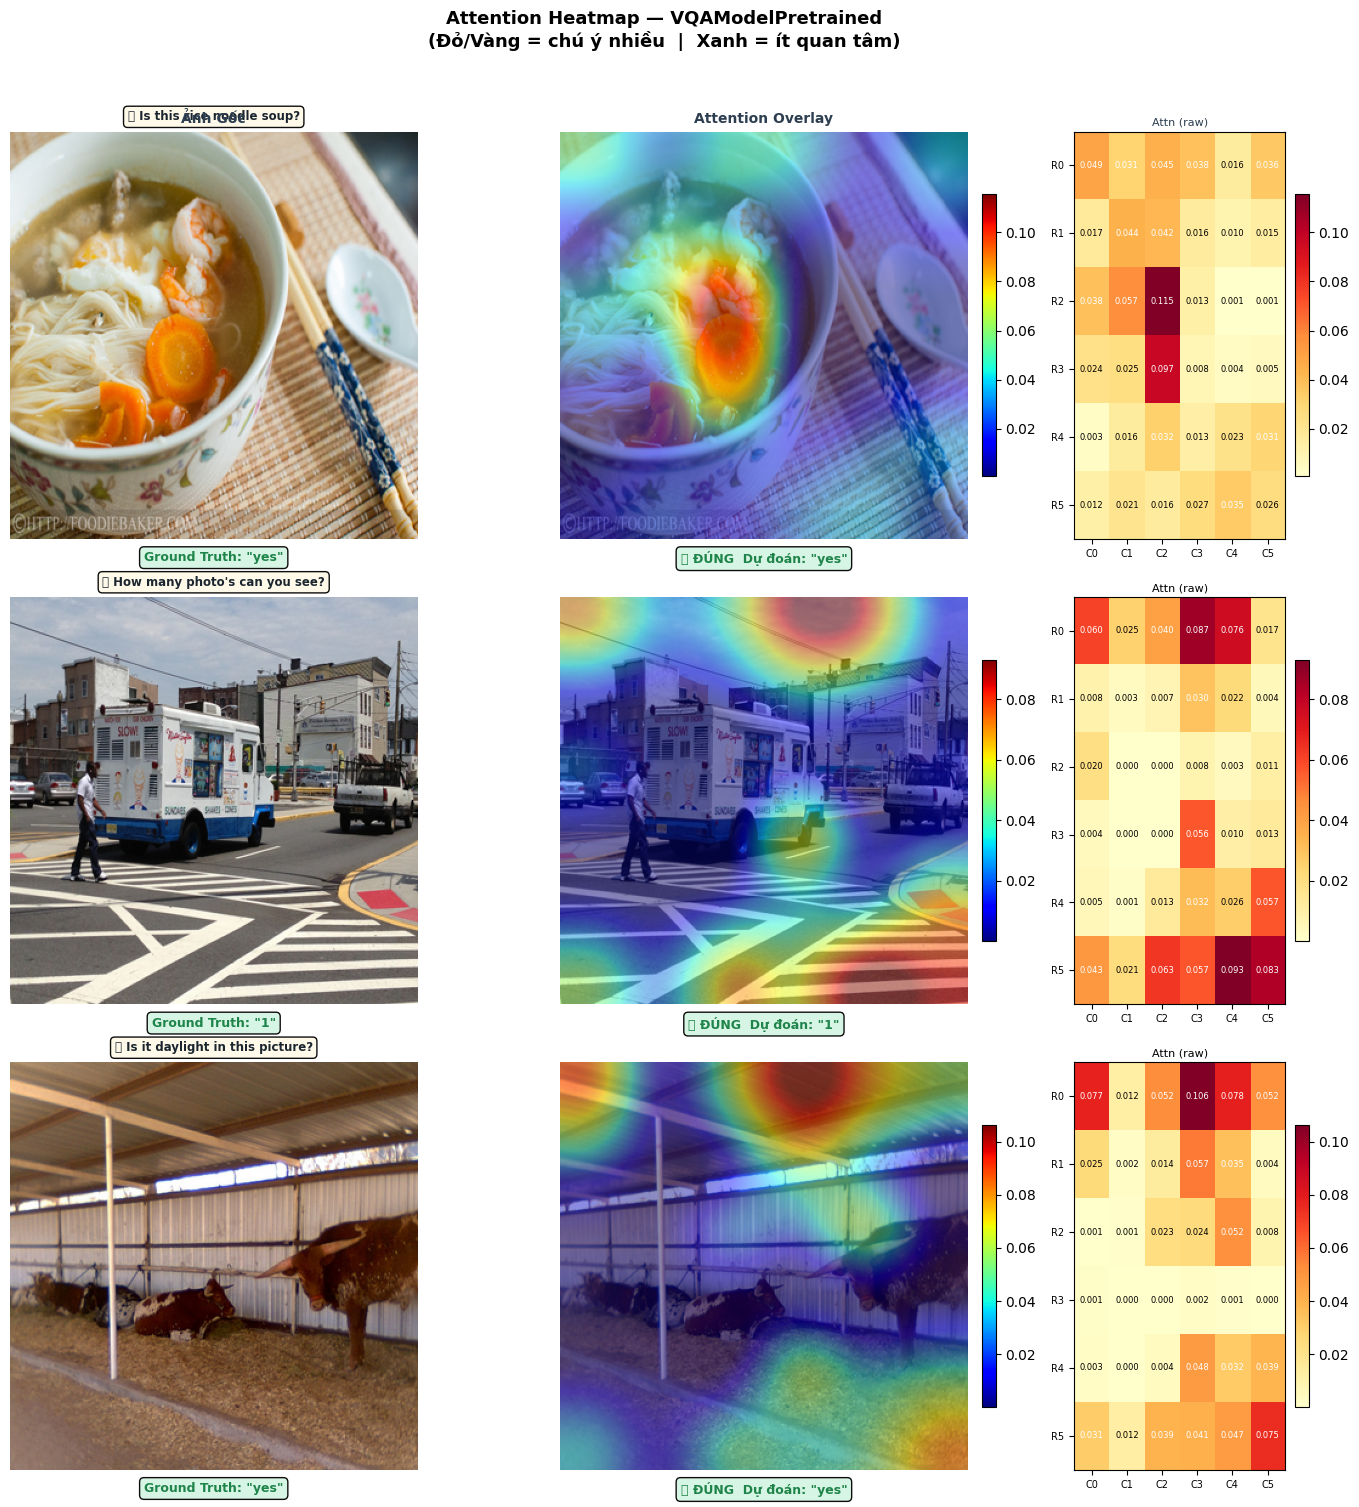

Đã lưu: logs/attention_heatmap.png


In [ ]:
@torch.no_grad()
def visualize_attention(model, val_loader, vocab, device, n_samples=3,
                        save_path='logs/attention.png', prefer_correct=True):
    """
    Lấy n_samples ví dụ từ val_loader, vẽ ảnh gốc + heatmap attention.
    prefer_correct=True: ưu tiên lấy mẫu dự đoán ĐÚNG trước.
    """
    model.eval()
    id2ans = {v: k for k, v in vocab.answer_word2idx.items()}

    correct_samples = []
    wrong_samples   = []

    for batch in val_loader:
        imgs    = batch['image_features'].to(device)
        ques    = batch['question'].to(device)
        q_txt   = batch['question_text']
        a_txt   = batch['answer_text']
        img_ids = batch['image_id']

        preds, attn_w = model(imgs, ques)
        pred_strs = [decode_tokens(preds[i].cpu().tolist(), id2ans) for i in range(imgs.size(0))]

        for i in range(imgs.size(0)):
            item = {
                'img_id' : img_ids[i].item(),
                'q_text' : q_txt[i],
                'gt'     : a_txt[i],
                'pred'   : pred_strs[i],
                'attn'   : attn_w[i].cpu().numpy(),  # [36]
            }
            if pred_strs[i].strip().lower() == a_txt[i].strip().lower():
                correct_samples.append(item)
            else:
                wrong_samples.append(item)

        # Dừng sớm nếu đủ mẫu
        if len(correct_samples) >= n_samples and not prefer_correct:
            break
        if len(correct_samples) + len(wrong_samples) >= n_samples * 5:
            break

    # Ưu tiên mẫu đúng, nếu thiếu thì bổ sung mẫu sai
    if prefer_correct:
        collected = correct_samples[:n_samples]
        if len(collected) < n_samples:
            collected += wrong_samples[:n_samples - len(collected)]
    else:
        collected = (correct_samples + wrong_samples)[:n_samples]

    print(f"  Tìm được {len(correct_samples)} mẫu đúng / {len(wrong_samples)} mẫu sai")
    print(f"  Hiển thị {len(collected)} mẫu ({sum(1 for s in collected if s['pred'].strip().lower()==s['gt'].strip().lower())} đúng)")

    # ── Layout: mỗi hàng gồm 3 cột: ảnh gốc | heatmap overlay | attn grid ──
    fig, axes = plt.subplots(len(collected), 3,
                             figsize=(14, 5 * len(collected)),
                             gridspec_kw={'width_ratios': [2, 2, 1]})
    if len(collected) == 1:
        axes = [axes]

    fig.suptitle('Attention Heatmap — VQAModelPretrained\n'
                 '(Đỏ/Vàng = chú ý nhiều  |  Xanh = ít quan tâm)',
                 fontsize=13, fontweight='bold', y=1.01)

    col_headers = ['Ảnh Gốc', 'Attention Overlay', 'Attention Grid 6×6']
    for col, header in enumerate(col_headers):
        axes[0][col].set_title(header, fontsize=10, fontweight='bold',
                               color='#2c3e50', pad=6)

    for row, sample in enumerate(collected):
        img_id = sample['img_id']
        img_path = None
        for split in ('val2014', 'train2014'):
            p = os.path.join('data', 'images', split,
                             f'COCO_{split}_{img_id:012d}.jpg')
            if os.path.exists(p):
                img_path = p
                break

        # Load ảnh
        try:
            pil_img = Image.open(img_path).convert('RGB').resize((336, 336))
            img_np  = np.array(pil_img) / 255.0
        except Exception:
            pil_img = None
            img_np  = np.zeros((336, 336, 3))

        # Tính heatmap
        attn_grid = sample['attn'].reshape(6, 6)
        attn_norm = (attn_grid - attn_grid.min()) / (attn_grid.max() - attn_grid.min() + 1e-8)
        attn_up   = cv2.resize(attn_norm, (336, 336), interpolation=cv2.INTER_CUBIC)
        heatmap   = plt.cm.jet(attn_up)[:, :, :3]
        blended   = np.clip(0.55 * img_np + 0.45 * heatmap, 0, 1)

        is_correct = sample['pred'].strip().lower() == sample['gt'].strip().lower()
        result_icon  = '✅ ĐÚNG' if is_correct else '❌ SAI'
        result_color = '#1e8449' if is_correct else '#c0392b'
        result_bg    = '#d5f5e3' if is_correct else '#fadbd8'

        q_short = sample['q_text'] if len(sample['q_text']) <= 60 \
                  else sample['q_text'][:60] + '...'

        # ── Cột 0: Ảnh gốc ───────────────────────────────────────────────────
        axes[row][0].imshow(img_np)
        axes[row][0].axis('off')
        # Câu hỏi trên ảnh
        axes[row][0].text(0.5, 1.02, f"❓ {q_short}",
                          transform=axes[row][0].transAxes,
                          ha='center', va='bottom', fontsize=8.5, fontweight='bold',
                          color='#1a252f',
                          bbox=dict(boxstyle='round,pad=0.35', facecolor='#fef9e7', alpha=0.95))
        # GT dưới ảnh
        axes[row][0].text(0.5, -0.03, f"Ground Truth: \"{sample['gt']}\"",
                          transform=axes[row][0].transAxes,
                          ha='center', va='top', fontsize=9, fontweight='bold',
                          color='#1e8449',
                          bbox=dict(boxstyle='round,pad=0.35', facecolor='#d5f5e3', alpha=0.95))

        # ── Cột 1: Heatmap overlay ────────────────────────────────────────────
        axes[row][1].imshow(blended)
        axes[row][1].axis('off')
        # Kết quả dự đoán dưới heatmap
        axes[row][1].text(0.5, -0.03,
                          f"{result_icon}  Dự đoán: \"{sample['pred']}\"",
                          transform=axes[row][1].transAxes,
                          ha='center', va='top', fontsize=9, fontweight='bold',
                          color=result_color,
                          bbox=dict(boxstyle='round,pad=0.35', facecolor=result_bg, alpha=0.95))
        # Colorbar
        sm = plt.cm.ScalarMappable(
            cmap='jet',
            norm=plt.Normalize(vmin=attn_grid.min(), vmax=attn_grid.max()))
        sm.set_array([])
        plt.colorbar(sm, ax=axes[row][1], fraction=0.03, pad=0.03)

        # ── Cột 2: Attention Grid 6×6 ─────────────────────────────────────────
        im = axes[row][2].imshow(attn_grid, cmap='YlOrRd', aspect='auto')
        axes[row][2].set_xticks(range(6))
        axes[row][2].set_yticks(range(6))
        axes[row][2].set_xticklabels([f'C{j}' for j in range(6)], fontsize=7)
        axes[row][2].set_yticklabels([f'R{i}' for i in range(6)], fontsize=7)
        axes[row][2].set_title('Attn (raw)', fontsize=8, pad=4)
        # Ghi giá trị vào từng ô
        for r in range(6):
            for c in range(6):
                axes[row][2].text(c, r, f'{attn_grid[r, c]:.3f}',
                                  ha='center', va='center', fontsize=6,
                                  color='white' if attn_grid[r, c] > attn_grid.mean() else 'black')
        plt.colorbar(im, ax=axes[row][2], fraction=0.06, pad=0.04)

    plt.tight_layout(rect=[0, 0.01, 1, 0.99])
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Đã lưu: {save_path}")


visualize_attention(_m_pretrained, val_loader, vocab, device, n_samples=3,
                    save_path='logs/attention_heatmap.png', prefer_correct=True)

## Phần 14: Demo Dự Đoán (Show Predictions)

Hiện thị các dự đoán từ cả 2 model trên cùng tập ảnh val để so sánh trực quan.  
Màu **xanh lá** = đúng hoàn toàn, màu **đỏ** = sai.

/tmp/ipykernel_366/2594980498.py:125: UserWarning: Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
/tmp/ipykernel_366/2594980498.py:125: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
/tmp/ipykernel_366/2594980498.py:125: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
/tmp/ipykernel_366/2594980498.py:125: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
/tmp/ipykernel_366/2594980498.py:125: UserWarning: Glyph 128312 (\N{SMALL ORANGE DIAMOND}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing

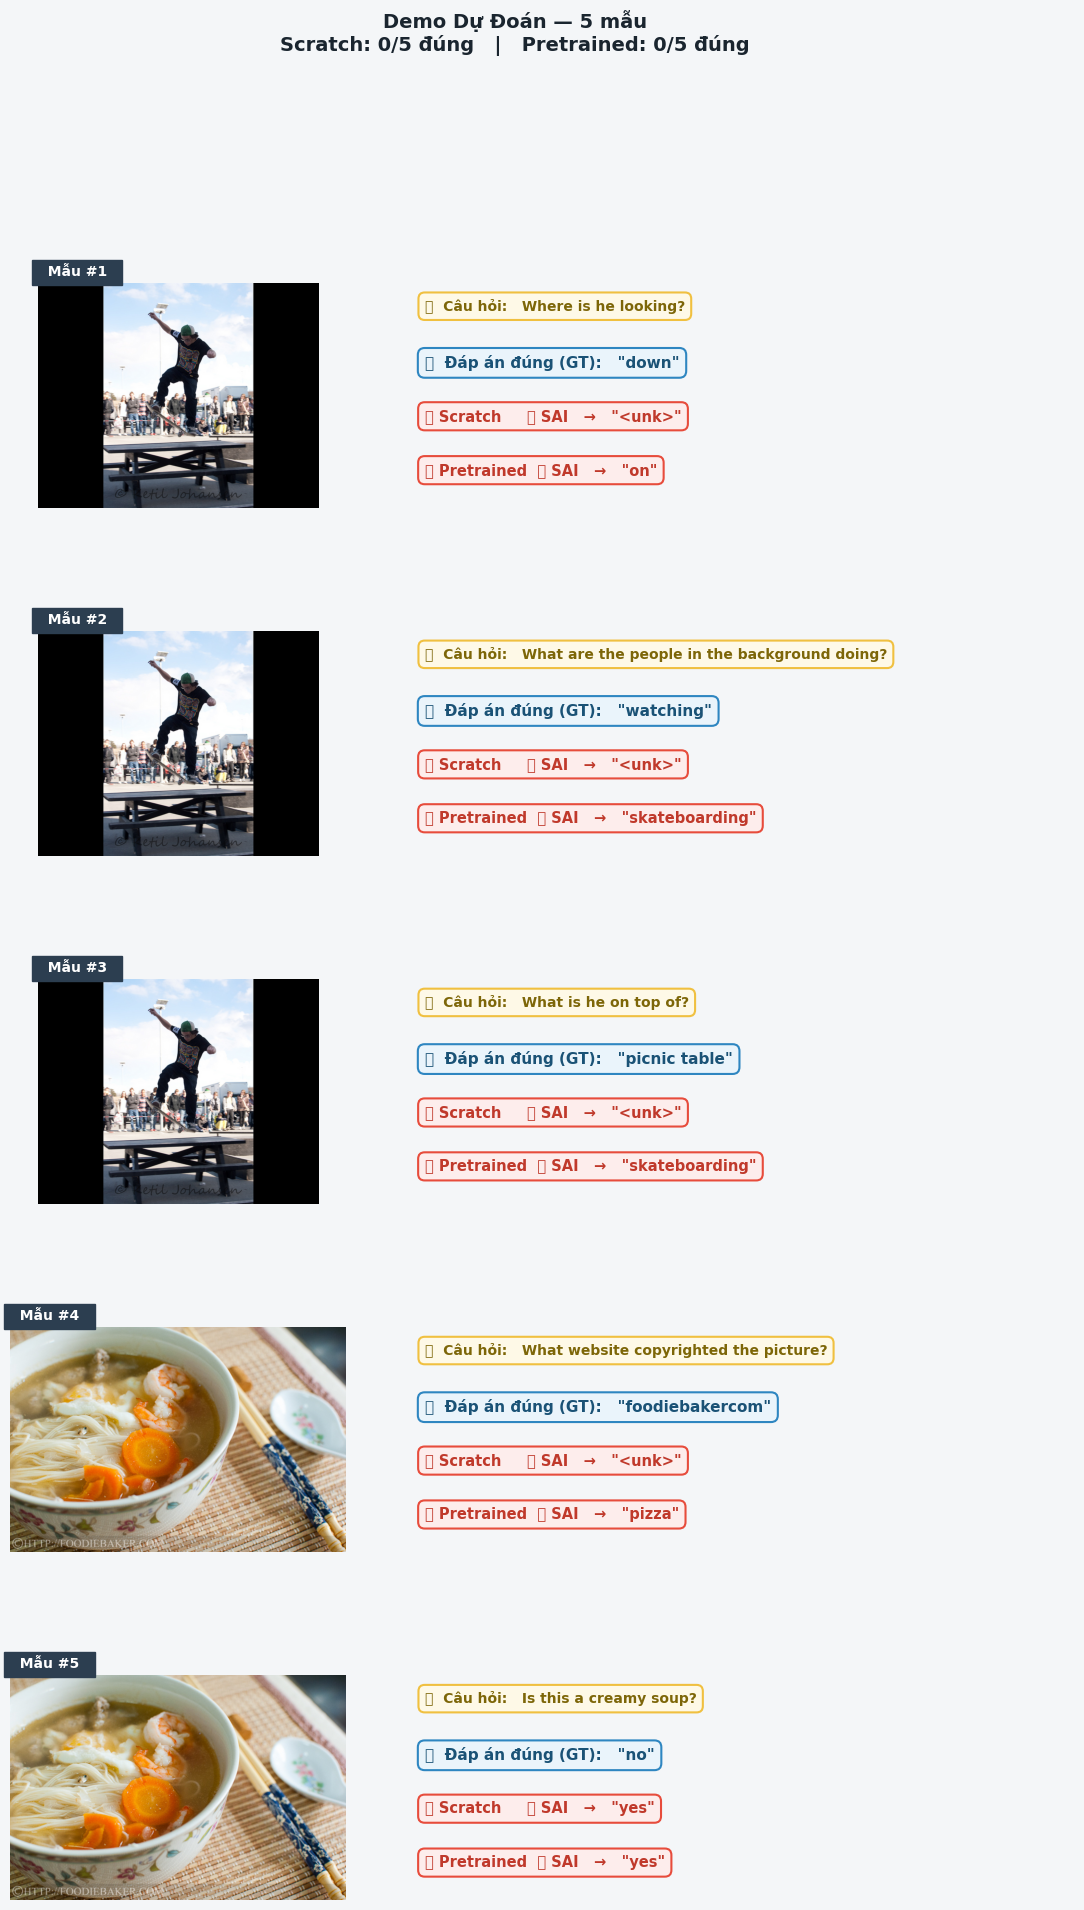

  Đã lưu: logs/predictions.png
  Tổng kết: Scratch 0/5  |  Pretrained 0/5


In [ ]:
@torch.no_grad()
def show_predictions(model_scratch, model_pretrained, val_loader, vocab, device,
                     n_samples=5, save_path='logs/predictions.png'):
    """
    Hiển thị n_samples dự đoán theo layout dễ đọc:
      [Ảnh]  |  [Câu hỏi / GT / Scratch / Pretrained — mỗi thứ 1 box màu]

    Không lặp lại ảnh 3 lần như trước.
    """
    id2ans = {v: k for k, v in vocab.answer_word2idx.items()}
    model_scratch.eval(); model_pretrained.eval()

    # ── Thu thập mẫu ──────────────────────────────────────────────────────────
    samples = []
    for batch in val_loader:
        imgs    = batch['image_features'].to(device)
        ques    = batch['question'].to(device)
        q_txt   = batch['question_text']
        a_txt   = batch['answer_text']
        img_ids = batch['image_id']

        preds_sc    = model_scratch(imgs, ques)
        preds_pt, _ = model_pretrained(imgs, ques)

        for i in range(imgs.size(0)):
            samples.append({
                'img_id' : img_ids[i].item(),
                'q'      : q_txt[i],
                'gt'     : a_txt[i],
                'pred_sc': decode_tokens(preds_sc[i].cpu().tolist(), id2ans),
                'pred_pt': decode_tokens(preds_pt[i].cpu().tolist(), id2ans),
            })
            if len(samples) >= n_samples:
                break
        if len(samples) >= n_samples:
            break

    # ── Đếm kết quả tổng quát ─────────────────────────────────────────────────
    sc_correct = sum(s['pred_sc'].strip().lower() == s['gt'].strip().lower() for s in samples)
    pt_correct = sum(s['pred_pt'].strip().lower() == s['gt'].strip().lower() for s in samples)

    # ── Layout: mỗi hàng = [ảnh | panel thông tin] ───────────────────────────
    fig = plt.figure(figsize=(14, 4.2 * n_samples))
    fig.patch.set_facecolor('#f4f6f8')

    title = (f"Demo Dự Đoán — {n_samples} mẫu\n"
             f"Scratch: {sc_correct}/{n_samples} đúng   |   "
             f"Pretrained: {pt_correct}/{n_samples} đúng")
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01, color='#1a252f')

    gs = fig.add_gridspec(n_samples, 2, width_ratios=[1, 1.8],
                          hspace=0.55, wspace=0.06)

    for row, s in enumerate(samples):
        sc_ok = s['pred_sc'].strip().lower() == s['gt'].strip().lower()
        pt_ok = s['pred_pt'].strip().lower() == s['gt'].strip().lower()

        # ── Cột 0: Ảnh ────────────────────────────────────────────────────────
        ax_img = fig.add_subplot(gs[row, 0])
        img_path = None
        for split in ('val2014', 'train2014'):
            p = os.path.join('data', 'images', split,
                             f'COCO_{split}_{s["img_id"]:012d}.jpg')
            if os.path.exists(p):
                img_path = p; break
        try:
            ax_img.imshow(Image.open(img_path).convert('RGB'))
        except Exception:
            ax_img.imshow(np.full((224, 224, 3), 200, dtype=np.uint8))
            ax_img.text(0.5, 0.5, '[Ảnh chưa tải]', ha='center', va='center',
                        transform=ax_img.transAxes, fontsize=10, color='gray')
        ax_img.axis('off')
        ax_img.set_title(f'  Mẫu #{row + 1}  ', fontsize=10, fontweight='bold',
                         color='white', backgroundcolor='#2c3e50', pad=5, loc='left')

        # ── Cột 1: Panel thông tin ─────────────────────────────────────────────
        ax_info = fig.add_subplot(gs[row, 1])
        ax_info.set_facecolor('#ffffff')
        ax_info.axis('off')
        ax_info.set_xlim(0, 1)
        ax_info.set_ylim(0, 1)

        q_display = s['q'] if len(s['q']) <= 72 else s['q'][:72] + '…'

        # ┌─ Câu hỏi ───────────────────────────────────────────────────────────
        ax_info.text(0.04, 0.93,
                     f"❓  Câu hỏi:   {q_display}",
                     va='top', fontsize=10, fontweight='bold', color='#7d6608',
                     bbox=dict(boxstyle='round,pad=0.45', facecolor='#fef9e7',
                               edgecolor='#f0c040', lw=1.5),
                     transform=ax_info.transAxes)

        # ┌─ Đáp án đúng ───────────────────────────────────────────────────────
        ax_info.text(0.04, 0.68,
                     f"📌  Đáp án đúng (GT):   \"{s['gt']}\"",
                     va='top', fontsize=11, fontweight='bold', color='#1a5276',
                     bbox=dict(boxstyle='round,pad=0.45', facecolor='#eaf4fb',
                               edgecolor='#2e86c1', lw=1.5),
                     transform=ax_info.transAxes)

        # ┌─ Scratch ───────────────────────────────────────────────────────────
        sc_icon  = '✅ ĐÚNG' if sc_ok else '❌ SAI'
        sc_color = '#1e8449' if sc_ok else '#c0392b'
        sc_bg    = '#eafaf1' if sc_ok else '#fdedec'
        sc_edge  = '#1e8449' if sc_ok else '#e74c3c'
        ax_info.text(0.04, 0.44,
                     f"🔹 Scratch     {sc_icon}   →   \"{s['pred_sc']}\"",
                     va='top', fontsize=10.5, fontweight='bold', color=sc_color,
                     bbox=dict(boxstyle='round,pad=0.45', facecolor=sc_bg,
                               edgecolor=sc_edge, lw=1.5),
                     transform=ax_info.transAxes)

        # ┌─ Pretrained ────────────────────────────────────────────────────────
        pt_icon  = '✅ ĐÚNG' if pt_ok else '❌ SAI'
        pt_color = '#1e8449' if pt_ok else '#c0392b'
        pt_bg    = '#eafaf1' if pt_ok else '#fdedec'
        pt_edge  = '#1e8449' if pt_ok else '#e74c3c'
        ax_info.text(0.04, 0.20,
                     f"🔸 Pretrained  {pt_icon}   →   \"{s['pred_pt']}\"",
                     va='top', fontsize=10.5, fontweight='bold', color=pt_color,
                     bbox=dict(boxstyle='round,pad=0.45', facecolor=pt_bg,
                               edgecolor=pt_edge, lw=1.5),
                     transform=ax_info.transAxes)

    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Đã lưu: {save_path}")
    print(f"  Tổng kết: Scratch {sc_correct}/{n_samples}  |  Pretrained {pt_correct}/{n_samples}")


show_predictions(_m_scratch, _m_pretrained, val_loader, vocab, device,
                 n_samples=5, save_path='logs/predictions.png')

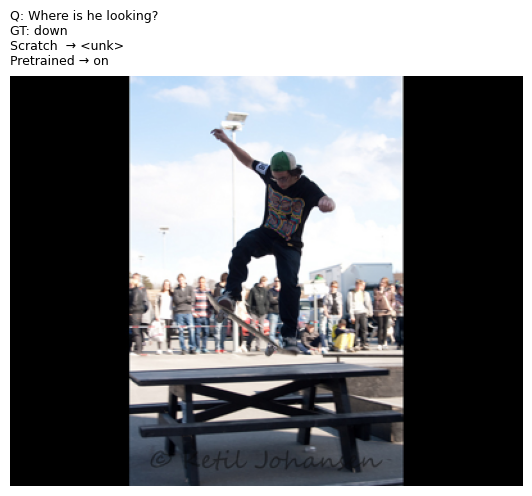


  Câu hỏi    : Where is he looking?
  GT          : down
  Scratch     : <unk>
  Pretrained  : on


In [ ]:

@torch.no_grad()
def predict_single(img_path, question_text, model, vocab, extractor, device,
                   is_pretrained=False):
    """
    Dự đoán câu trả lời cho 1 ảnh + 1 câu hỏi bất kỳ.

    Params:
        img_path      : đường dẫn ảnh
        question_text : câu hỏi tiếng Anh
        model         : VQAModelScratch hoặc VQAModelPretrained
        vocab         : VQAVocabulary instance
        extractor     : ImageFeatureExtractor instance
        device        : cuda / cpu
        is_pretrained : True nếu model là VQAModelPretrained
    Returns:
        answer_str (str)
    """
    model.eval()
    id2ans = {v: k for k, v in vocab.answer_word2idx.items()}

    # Trích xuất đặc trưng ảnh
    img_feat = extractor.extract(img_path)  # numpy array [36, 2048]
    img_feat = torch.from_numpy(img_feat).unsqueeze(0).to(device)  # [1,36,2048]

    # Encode câu hỏi
    ques_ids = vocab.encode_question(question_text, max_len=14)
    ques_t   = torch.tensor(ques_ids, dtype=torch.long, device=device).unsqueeze(0)  # [1,14]

    # Inference
    if is_pretrained:
        preds, _ = model(img_feat, ques_t)   # [1, seq]
    else:
        preds    = model(img_feat, ques_t)   # [1, seq]

    answer = decode_tokens(preds[0].cpu().tolist(), id2ans)
    return answer


# ── Demo predict_single ────────────────────────────────────────────────────────
# Lấy 1 ảnh bất kỳ từ val set để test
demo_batch  = next(iter(val_loader))
demo_img_id = demo_batch['image_id'][0].item()
demo_q_txt  = demo_batch['question_text'][0]
demo_gt     = demo_batch['answer_text'][0]

for spl in ('val2014', 'train2014'):
    demo_path = os.path.join('data', 'images', spl, f'COCO_{spl}_{demo_img_id:012d}.jpg')
    if os.path.exists(demo_path): break

ans_sc = predict_single(demo_path, demo_q_txt, _m_scratch,    vocab, extractor, device, is_pretrained=False)
ans_pt = predict_single(demo_path, demo_q_txt, _m_pretrained, vocab, extractor, device, is_pretrained=True)

# Hiệu thị kết quả
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
try:
    pil = Image.open(demo_path).convert('RGB').resize((400, 320))
    ax.imshow(pil)
except Exception:
    ax.imshow(np.zeros((320, 400, 3), dtype=np.uint8))
ax.axis('off')
title = (f"Q: {demo_q_txt}\n"
         f"GT: {demo_gt}\n"
         f"Scratch  → {ans_sc}\n"
         f"Pretrained → {ans_pt}")
ax.set_title(title, fontsize=9, loc='left', pad=8)
plt.tight_layout()
plt.savefig('logs/demo_single.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n  Câu hỏi    : {demo_q_txt}")
print(f"  GT          : {demo_gt}")
print(f"  Scratch     : {ans_sc}")
print(f"  Pretrained  : {ans_pt}")

### Kết luận

- **Pretrained model** thường cho kết quả tốt hơn Scratch nhờ GloVe đã học biểu diễn ngữ nghĩa phong phú và SpatialAttention giúp model tập trung vào vùng ảnh đúng.
- **Teacher forcing** giúp huấn luyện ổn định nhưng cần lưu ý exposure bias khi inference.
- **Gradual unfreezing** của GloVe (freeze → unfreeze sau epoch 8) tránh phá vỡ pretrained knowledge quá sớm.